# IIA project GG3: Neural Data Analysis

Easter 2026<br>
Project Leader: Guillaume Hennequin (gjeh2)<br>
(project originally created by Yashar Ahmadian)

## Logistics

For logistics, including all important deadlines, please refer to the [course's Moodle page](https://www.vle.cam.ac.uk/course/view.php?id=250261).

  
## Computing notes

This project is based on this jupyter nootebook, accessible from the project's [github repository](https://github.com/ghennequin/gg3) along with other `.py` modules; you have at least 2 options to run your code:
- option 1: clone the github repo and use your own python/jupyter environment on your laptop (vscode, ...)
- option 2: upload the `.ipynb` in your google drive through [Google colab](https://colab.research.google.com). This server-based solution might be the most convenient for group collaboration. However, note that compute credits are limited on Google colab, so you might want to run things locally (see above options) as much as possible, to save your budget for when things get more computationally heavy in Weeks 3 and 4. If you use colab, you will need to run the following:

In [14]:
mode = "local" # change this to "local" if you are on your own computer

if mode == "local":
    import models
elif mode == "colab":
    import requests
    url = 'https://github.com/ghennequin/gg3/blob/main/models.py?raw=true'
    r = requests.get(url)
    with open('models.py', 'w') as f:
        f.write(r.text)
    import models
else:
    raise Exception("mode must be either local or colab")

# Neuroscience Background

Background for the project is provided as a Jupyter notebook (`Background.ipynb` in the project's github repository).

# Main project question: what is the right model of LIP?

## Two hypotheses

As we saw in the Background section, classic studies suggested that LIP neurons which exhibit ramping activity in
their trial-averaged PSTH's are involved in evidence accumulation. However, the story became more complicated,
when in 2015, [Latimer et al.](https://www.science.org/doi/10.1126/science.aaa4056) provided evidence that most LIP neurons are better modelled as neurons with a "stepping firing rate". In this alternative model
 the rate does not continuously ramp up or down (albeit via a random walk) as in a drif-diffusion model.
Rather, the rate is piece-wise constant: it starts relatively low, but at some time point it jumps ("steps") up discontinuously to a higher firing rate level. The jump point is random and varies from trial to trial, according to some distribution.

#### -------------------------------   Figure 1   -------------------------------
<img src="figs/latimer-step-ramp.png" width=600 />

We will refer to these two competing hypotheses or models as the **ramping** and **stepping models**, respectively
(other common synonyms for the ramping model are "the drif-diffusion model", mentioned above, and "the diffusion-to-bound model"; we will also use **jump model** as synonymous with the stepping model.) 

In this project we aim to develop tools that allow us to reject or accept one of these hypotheses
based on observed spike trains. Understanding which of the two is a more accurate description of LIP activity is scientifically significant. The ramping hypothesis suggests that LIP cortex is responsible
for accumulating evidence to inform and make decisions. On the other hand, the binary nature of the stepping model
suggests that LIP is downstream of the evidence accumulating area, and may simply reflect, in its activity, the decision already made in an upstream area.

## Two generative models


So far, our two "models" have mostly remained conceptual and qualitative. At this high, conceptual level I will therefore refer to them as hypotheses instead: the ramping hypothesis vs. stepping hypothesis. However, in order to use the powerful tools of probability theory and machine learning, we need to turn these conceptual hypotheses into well-defined mathematical models.

### The common, abstract model structure

The ramping and stepping models to be described here and simulated in the project,  are examples of **probabilistic generative models**. Each model has a set of **parameters** (such as the drift rate of the ramping model), and it stochastically generates data, in our case spike trains. The systematic behaviour of these spike trains depends on the various model parameters. Mathematically, this stochastic relationship between the parameters and data is given by a conditional probability distribution

$$ P(\mathrm{data}| \Theta, M) $$

where $\Theta$ denotes the set of parameters and $M$ denotes the model (in our case $M$ = ramping, or $M =$ stepping). This conditional probability, when viewed as a function of $\Theta$, is called the model's **likelihood function**.
By (observed) "data" we mean a set of spike-trains recorded (in our case simulated) over many trials:

$$
\text{data} \equiv \{(n_t)_{t=1}^T\}.
$$

$n_t$ will sometimes be referred to as **observed variables**.

**Latent variables:** As generative models, the two models can also be simulated to generate spike trains. In order to do this, the two models first generate a firing rate function or time-series, $r_t$. The spike count, $n_t$, in a given time bin is then stochastically generated based solely on $r_t$. The rate sequence $r_t$ is itself a stochastic process, and depends on a set of *latent variables*. Latent variables are random variables that are so called because they are not directly observed by us (data-)scientists and engineers, but need to be inferred from observed data (the spike trains). In the simple version of the stepping model, with which we will start, there is only a single latent variable: the stepping time. The ramping model, on the other hand, generates a whole sequence of latent variables in each trial: these are the values of the ramping stochastic process, which is closely tied to the firing rate.

Since the latent variables (unlike the model parameters) vary from trial to trial, in each trial they need to be inferred from a single spike-train. By contrast, parameters which control the systematic behaviour of the model are shared across trials and will therefore be inferred from the entire dataset, i.e. the collection of spike trains in all trials.

**Discrete vs continuous time:** Both models are implemented in discrete time. Thus the varible $t$ above is an integer (index for the) time-step. We will denote the (fixed) total number of time steps in a trial by $T$. Real trials last on the order of 1 second, and we would want our time steps or time bins to be around 1 to 10 milliseconds. So, correspondingly, $T$ will be rather large, we will experiment with $T=$ 100 to 1000. For various purposes, we will need to convert from discrete to continuous time in seconds. For that purpose we will fix the trial duration at 1 second and thus interpret each time-step to have duration $1/T$ seconds; we will denote this by $dt$ here and in the code (thus $dt = 1/T$ seconds).

We will now describe the probabilistic structure of the two models in some detail.

### Stepping model

**Latent variables:** This is the simpler one of the two. The only latent variable of this model is the step time or **jump time**. I will denote the step time in trial $j$ by $\tau_j$. Since we work in discrete time, $\tau_j$ is a (non-negative) integer. In `models.py` the corresponding variable is called `jump` or (when containing the value of multiple trials) `jumps`. In each trial, the step time is sampled from some probability distribution:

$$ \tau \sim P(\tau) $$

In the provided code this distribution is a so-called **negative binomial distribution** (see [this](https://en.wikipedia.org/wiki/Negative_binomial_distribution)) with two parameters: $m$ and $r$. Here, $m$ sets the average step time, and as for $r$ ... that's left for you to figure out.

As we said above, in each trial, the firing rate sequence of this model is piece-wise constant. If we denote the jump time of trial $j$ by $\tau_j$, then for $t < \tau_j$, $r_t = R_0$ and for $t \geq \tau_j$, $r_t = R_h > R_0$, where the two constants $R_0$ and $R_h$ are part of the model parameters. We will refer to them as pre- and post-step firing rates. 

Finally, given the rate sequence, $r_t$, the spike counts in different timesteps are generated independently from a [Poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution):

$$ n_t \sim \mathrm{Poiss}(r_t dt) $$

Note  that since we measure rates in Hz, $dt$ has to be in seconds, in order to get the right dimensionless parameter (mean spike count) of of the Poisson distribution. 

**Fitted parameters:** $m, r, \text{ and } x_0$.

These are the parameters which you aim to infer from spike train datasets. $x_0$ is equivalent to $R_0$ and is given by $R_0/R_h$; think of it as the normalised pre-step rate (we use $x_0$ instead of $R_0$, to match the similar parameter in the ramping model). By definition $0< x_0 < 1$.

**"Fixed" parameters:** We will take $R_h$ as known/fixed, and will not infer it from data. For many project tasks we will fix it at $R_h = 50$ Hz. Though in early tasks you will explore its effects by varying it.

### Ramping model

**Latent variables:** This model, which approximates the continuous time drift-diffusion model, has a whole sequence of latent variables which we will denote by $x_t$. This variable is the so-called **decision variable**. The update equations for $x_t$ are discretised versions of the equation in Figure 3 (in `Background.ipynb`):

$$x_{t+1} = x_t + \beta dt + \sigma \sqrt{dt} \epsilon_t \qquad\qquad\qquad (1)$$

where 

$$\epsilon_t \overset{iid}{\sim} \mathcal{N}(0,1) \qquad\qquad (2)$$

(i.e. $\epsilon_t$ is sampled independently in each time step from the standard normal distribution, $\mathcal{N}(0,1)$, in other words, it has a Gaussian distribution with mean 0 and variance 1.) The initial condition is set via

$$
x_1 = x_0 + \sigma \sqrt{dt} \epsilon_0
$$

where $\epsilon_0$ is again standard normal, and $x_0$ is a model parameter (and not a latent variable,
as it is the same across all trials). (Note that, due to python indices starting from 0, the equation above will (implicitly) appear as `x[0] = x0 + sigma * np.random.randn()` in the code).

The firing rate in this model is a rectified and scaled version of $x_t$:

$$ r_t = R_h [x_t]_+ = R_h \max(0, x_t) $$

It is not hard to see that the sequential variables $x_t$ form a Markov chain (this has to do with the fact that $\epsilon_t$ in different trials are independent), and therefore the ramping model is an example of a **hidden Markov model (HMM)**. In fact, if you have taken 3F8, you will realise that $x_t$ is *almost* an AR(1) Gaussian Process. I said almost an AR(1) Gaussian process, because *when $x_t$ reaches 1, it will get stuck there for the rest of the trial*. (Equivalently, after this point, the firing rate, $r_t$, stays at its maximal level $R_h$.) This reflects the interpretation of $x_t$ as a decision variable, which upon reaching a pre-set bound or threshold, triggers the decision; in our case the bound is 1. 

Similar to the stepping model, given the rate sequence, $r_t$, the spike counts in different timesteps are generated independently from a Poisson distribution

$$ n_t \sim \mathrm{Poiss}(r_t dt) $$

**Fitted parameters:** $\beta, \sigma, \text{ and } x_0$.

$\beta$ and $\sigma$ control the systematic drift vs. stochasticity of the ramping variable $x_t$. Similar to the stepping model, $x_0$ sets the initial rate, $r_0$, via $r_0 = R_h x_0$. And again $0< x_0 < 1$.

**"Fixed" parameters:**  $R_h$, maximal rate, to be treated as known, as in the jumping model.

### Ignored stimulus dependence

In the full version of the ramping model, the magnitude and sign of $\beta$ depends on the coherence and the direction of motion of the RDM stimulus in that trial. However, for simplicity, in this project we assume $\beta$ is fixed in all trials and assume it is positive.

Similarly, in the full version of the stepping model, the post-jump rate can take two possible values $R_h > R_0$, as described above, or $R_l < R_0$. We can call $R_h$ and $R_l$ the up or down rates, and call their normalized values of 1 and $R_l/R_h < 1$ up and down states. The probability with which the model transition up or down after the jump time can again depend on the coherence and direction of motion of the RDM stimulus in a trial. But again, to simplify the model, we ignore this fact. In fact, for most of the project we work with a stepping model without a down state.

# Approximate timeline


Our task in this project is to slowly build up techniques to ultimately reject or accept one or the other hypothesis based on 
recorded (or, in our case, simulated) spike trains. We will do this by progressively moving from lower to higher levels of 
probabilistic inference. 


- WEEK 1: explore the behaviour of the two models based on simulator code provided to you in `models.py`, and take preliminary steps towards developing a discrete-state HMM approximation to them, which allows us to apply  powerful inference tools. 

- WEEK 2: develop tools to carry out **single-trial inference**  of the models' latent variables from observed on single spike trains, taking advantage of their HMM formulation.

- WEEKS 2-3: Assuming model $M$ is the true model underlying data, use Bayesian or maximum-likelihood inference to infer or estimate model parameters, $\Theta$, based on observed data, that is, many trials of simulated spike trains. 

- WEEKS 3-4: Use Bayesian inference to select/reject one or the other hypothesis/model, given a dataset of spike trains.

Depending on feedback and pace of progress, in week 4 we will also investigate the consequences of model mismatch. Since "all models are wrong (but some are useful)", what can we say about the possibility of reaching wrong conclusions regarding our alternative conceptual hypotheses, due to some arbitrary choices we had to make in translating those conceptual models to concrete mathematical models?

# Week 1: Model simulation and behaviour



### Task 1.1 - basic spike rasters

Study the code in `models.py`, specifically the implementations of the two models in the `StepModel` and `RampModel` classes. The main part to study (and relate to the mathematical discussion above) is their `simulate` method/function. You create an object instance of each model by providing the model parameters (both "fit" and "fixed" parameters, as named above) to the class constructors: e.g. `ramp = RampModel(beta=..., sigma=..., ...)`. (Ignore the other input arguments in the class constructor `__init__` for now, and leave them at their default values.) Once a model object is created you can use its `simulate` method to get an array of spike trains over multiple trials. (For usage see the docstring (or run help via `ramp.simulate?`.) `simulate` will also return the generated latent variables, and, optionally, the firing rates in different trials. 

Visualise the simulated spike trains by writing code to make so-called "spike raster" plots. See the bottom row of Figure 1 above for example spike rasters: different rows represent the spike trains in different trials, and spikes are shown by dots. (you can put a dot for every nonzero $n_t$, even if the nonzero value is more than 1; this is unlikely if you keep `Rh` below 50 Hz and use a `T` of at least 100 (recommended)). At this stage it should not be time-consuming to use higher `T`'s as well, e.g. `T = 1000` (corresponding to 1 millisecond time-steps). If you are simulating hundreds of trials, you don't want to include all of them in the raster. Use your common sense to decide how many trials to include in the raster; this is a visualisation tool used to get an idea of how spike trains behave qualitatively by seeing a good number of example.

Vary the parameters of each model and generate spike rasters in different regions of the parameter space, trying to find qualitatively different behavior. The default values of the parameters give you a first guess or the right order of magnitude for the value of different parameters. (For `m` and `r` of the step model, note that they should scale with the `T` that you will be using for the simulation; in particular, for more interesting / relevant results, you would want to start with values of `m` around `T / 2` so that the steps happen on average in the middle of the trial.)

What systematic patterns can you detect? 

In your spike raster plots mark the jump times in different trials (by some marker superposed over the spike). Also make histograms of jump times. What is the effect of the `r` parameter on the behaviour of the stepping model?

Similarly make plots of the trajectories of $x_t$ or $r_t$ (of the ramp model) in several trials, in a single plot. You can extract the time when $x_t$ of the ramping model hits its upper bound of 1 (equivalently $r_t$ reaches $R_h$), and histogram that as well. How do `beta` and `sigma` affect this histogram or the behaviour of the $x_t$ trajectories?

#### Task 1.1 solution

The cells below use the supplied `StepModel` and `RampModel` simulators to make spike rasters, event-time histograms, and ramp trajectories.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from models import StepModel, RampModel
from models import lo_histogram


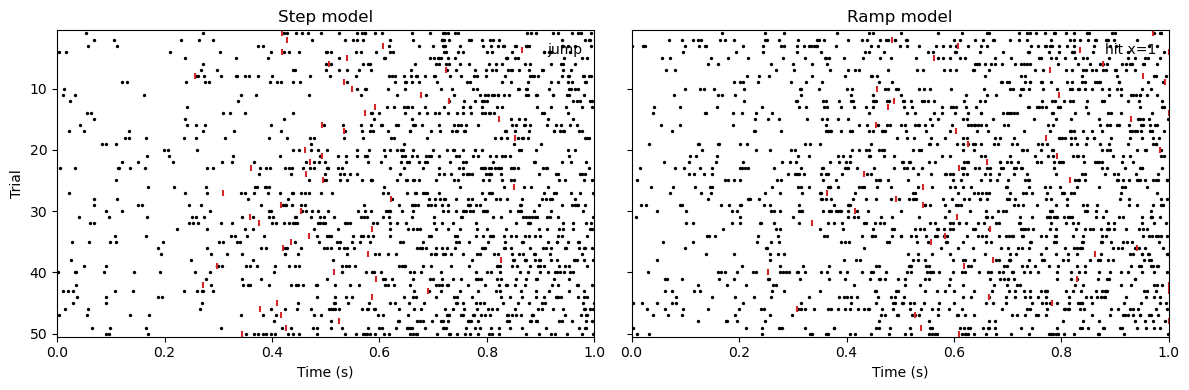

In [7]:
np.random.seed(2)

T = 1000
Ntrials = 200
n_plot = 50
Rh = 50
time = np.arange(T) / T

def ramp_hit_times(xs):
    return np.argmax(np.hstack((xs, np.ones((xs.shape[0], 1)))) >= 1, axis=1)

def plot_raster(ax, spikes, title, event_times=None, event_label="event"):
    trials = min(n_plot, spikes.shape[0])
    trial_idx, time_idx = np.nonzero(spikes[:trials] > 0)
    ax.scatter(time_idx / T, trial_idx + 1, s=8, color="black", marker=".")

    if event_times is not None:
        ax.scatter(event_times[:trials] / T, np.arange(trials) + 1,
                   s=22, color="tab:red", marker="|", label=event_label)
        ax.legend(frameon=False, loc="upper right")

    ax.set(title=title, xlabel="Time (s)", xlim=(0, 1), ylim=(0.5, trials + 0.5))
    ax.invert_yaxis()

step = StepModel(m=T // 2, r=10, x0=0.2, Rh=Rh)
ramp = RampModel(beta=1.2, sigma=0.35, x0=0.15, Rh=Rh)  # Params achieve similar 'jump' times as the step model

step_spikes, step_jumps, step_rates = step.simulate(Ntrials=Ntrials, T=T)
ramp_spikes, ramp_xs, ramp_rates = ramp.simulate(Ntrials=Ntrials, T=T)
ramp_hits = ramp_hit_times(ramp_xs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_raster(axes[0], step_spikes, "Step model", step_jumps, "jump")
plot_raster(axes[1], ramp_spikes, "Ramp model", ramp_hits, "hit x=1")
axes[0].set_ylabel("Trial")
plt.tight_layout()


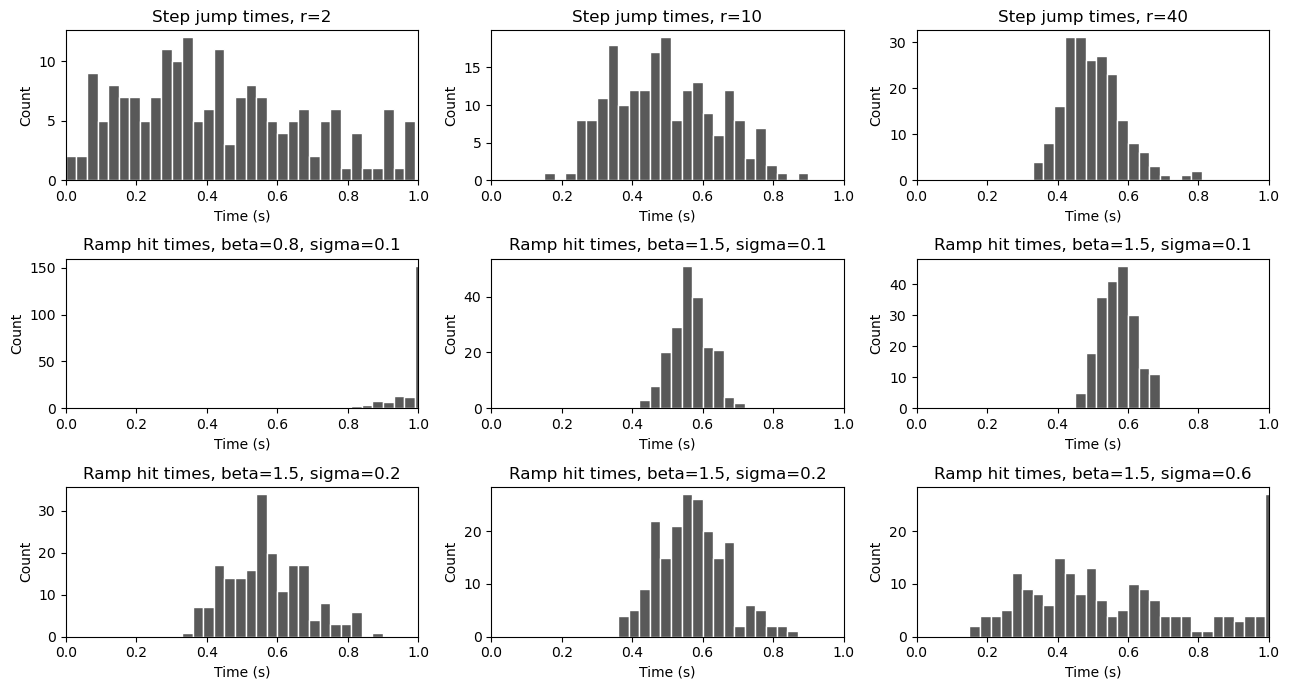

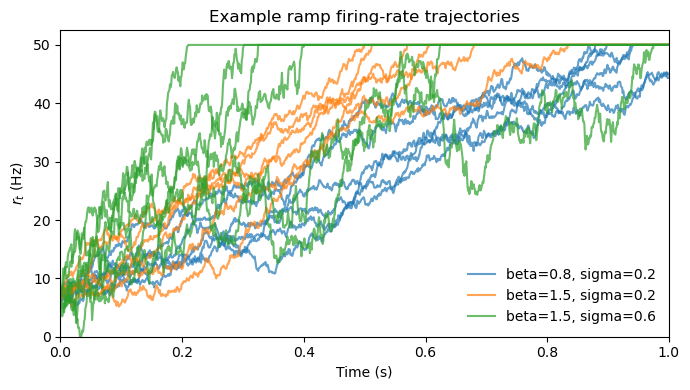

In [8]:
def plot_time_hist(ax, values, title):
    bin_width = 30 # ms
    bins = np.arange(0, T + bin_width, bin_width)
    values_in_trial = values[values <= T]
    counts, _ = np.histogram(values_in_trial, bins)
    ax.bar(bins[:-1] / T, counts, width=np.diff(bins) / T,
           align="edge", color="0.35", edgecolor="white")
    ax.set(title=title, xlabel="Time (s)", ylabel="Count", xlim=(0, 1))

step_rs = [2, 10, 40]
ramp_params = [(0.8, 0.2), (1.5, 0.2), (1.5, 0.6)]

fig, axes = plt.subplots(3, 3, figsize=(13, 7))

for ax, r in zip(axes[0], step_rs):
    model = StepModel(m=T // 2, r=r, x0=0.2, Rh=Rh)  # model all step models with mean jump time centered.
    _, jumps, _ = model.simulate(Ntrials=Ntrials, T=T)
    plot_time_hist(ax, jumps, f"Step jump times, r={r}")

sigma = 0.1 # fixed sigma for beta sweep
for ax, (beta, _) in zip(axes[1], ramp_params):
    model = RampModel(beta=beta, sigma=sigma, x0=0.15, Rh=Rh)
    _, xs, _ = model.simulate(Ntrials=Ntrials, T=T)
    hits = ramp_hit_times(xs)
    plot_time_hist(ax, hits, f"Ramp hit times, beta={beta}, sigma={sigma}")

beta = 1.5  # fixed for sigma sweep
for ax, (_, sigma) in zip(axes[2], ramp_params):
    model = RampModel(beta=beta, sigma=sigma, x0=0.15, Rh=Rh)
    _, xs, _ = model.simulate(Ntrials=Ntrials, T=T)
    hits = ramp_hit_times(xs)
    plot_time_hist(ax, hits, f"Ramp hit times, beta={beta}, sigma={sigma}")

plt.tight_layout()

fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, (beta, sigma) in enumerate(ramp_params):
    model = RampModel(beta=beta, sigma=sigma, x0=0.15, Rh=Rh)
    _, _, rates = model.simulate(Ntrials=6, T=T)
    color = colors[i]
    for j, rate in enumerate(rates):
        label = f"beta={beta}, sigma={sigma}" if j == 0 else None
        ax.plot(time, rate, color=color, alpha=0.7, label=label)

ax.legend(frameon=False)
ax.set(title="Example ramp firing-rate trajectories", xlabel="Time (s)", ylabel="$r_t$ (Hz)", xlim=(0, 1), ylim=(0, Rh * 1.05))
plt.tight_layout()


**Observations.** In the step model, increasing `r` while keeping `m` fixed makes the jump-time histogram narrower and less variable around the mean jump time. Small `r` gives much broader, more skewed jump times, so different trials step up at quite different moments.

Note that 'r' acts as a variance, but literally means the number of successes for the negative binomial distribution that the jump time 'tau' is sampled from.

In the ramp model, larger `beta` drives trajectories to the upper bound earlier. Larger `sigma` makes trajectories and hit times more variable, so some trials reach the bound early while others remain low for longer.

Note that a very small 'sigma' produces a near-vertical 'jump' line in the raster plot.


### Task 1.2 - PSTHs

PSTH (peri-stimulus time histogram) is an important data analysis tool used in neuroscience. This  is a statistical estimate of the trial-averaged firing rate as a function of time, based on recordings of spike trains in multiple experimental trials. It is obtained by binning / histogramming spikes (e.g. using `np.histogram`) in different time bins and averaging the resulting spike counts over many trials (you can also divide by `dt` to turn mean spike counts into firing rate, in units of Hz).

Write code to construct and plot PSTH's in different regions of each model's parameter space. Note how the PSTH fluctuates randomly from dataset to dataset. It is better to do some sort of (temporal) smoothing in order to reduce these fluctuations and the jaggedness of the PSTH. You can use either a sliding window (e.g. a boxcar window/functin) averaging, or simply use time bins that are larger than the oridinal time steps (e.g. 50 milliseconds -- or 5 timesteps if you are using a `dt` of 10 ms, corresponding to `T = 100`). The smooth ramping firing rate curves in Figure 4 of the [Background](https://github.com/ghennequin/gg3/blob/main/Background.ipynb) are examples of smoothed PSTH's.

Even with the smoothing there will be fluctuations in the PSTH from dataset to dataset. How does the strength of these fluctuations depend on (or scale with) the number of trials (in each dataset)? Try to be quantitative about this. For the rest of this task use a high number of trials (e.g. 5000) to minimise these fluctuations. (But note that in real experiments the number of trials rarely exceeds a few hundred -- so for later tasks we will bring the number down.)

Finally, try to find parameter regimes that make the PSTH of the stepping model very close to that of the ramp model. (First make sure the ramp model's PSTH look qualitatively like the classic ramping PSTH's in the LIP experiments.) In which parameter regions does this fail drastically, and in which regimes are the two PSTH's nearly indistinguishable?

#### Task 1.2 solution

The aim here is to use PSTHs to understand which parts of the step and ramp parameter spaces can look similar after trial averaging. I use `T = 1000` here, so each simulation step is 1 ms and a 50 ms smoothing/binning window corresponds to 50 time steps.

In [9]:
# Common constants for the Task 1.2 plots.
np.random.seed(2)

T = 1000
Rh = 50
x0 = 0.2
Ntrials = 600

time = np.arange(T) / T
fine_bins = np.linspace(0, 1, T + 1)
bin_width = 0.05  # 50 ms = 50 time steps when T = 1000
wide_bins = np.arange(0, 1 + bin_width, bin_width)
wide_centres = 0.5 * (wide_bins[:-1] + wide_bins[1:])
window_steps = round(bin_width * T)


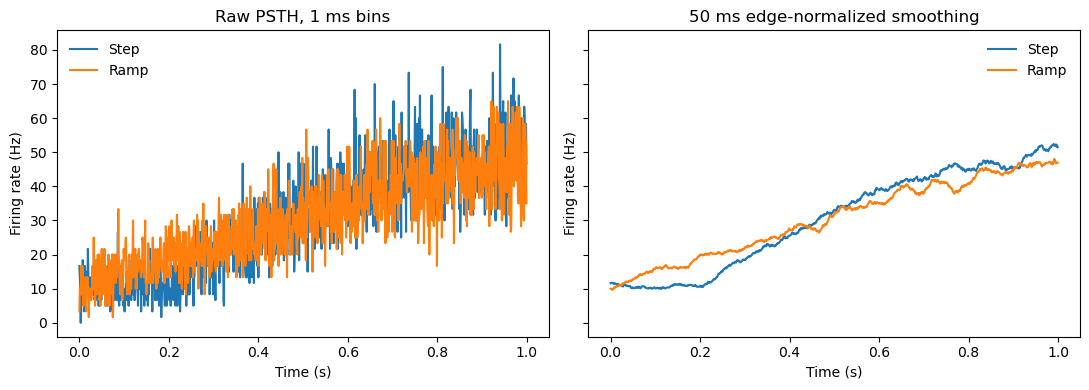

In [10]:
# Basic PSTHs, using raw 1 ms bins and fixed 50 ms sliding-window smoothing.
# The bin edges used here lie on the simulation grid, so summing by integer
# time-bin indices avoids floating-point histogram edge artifacts.
def binned_counts(spikes, bins):
    edges = np.rint(bins * T).astype(int)
    return np.stack([spikes[:, start:end].sum(axis=1) for start, end in zip(edges[:-1], edges[1:])], axis=1)


def psth(spikes, bins):
    counts = binned_counts(spikes, bins)
    return counts.mean(axis=0) / np.diff(bins)


def smooth_boxcar(y, width):
    window = np.ones(width)
    numerator = np.convolve(y, window, mode="same")
    denominator = np.convolve(np.ones_like(y), window, mode="same")
    return numerator / denominator


step = StepModel(m=T // 2, r=5, x0=x0, Rh=Rh)
ramp = RampModel(beta=0.85, sigma=0.25, x0=x0, Rh=Rh)

step_spikes, _, _ = step.simulate(Ntrials=Ntrials, T=T)
ramp_spikes, _, _ = ramp.simulate(Ntrials=Ntrials, T=T)
step_raw = psth(step_spikes, fine_bins)
ramp_raw = psth(ramp_spikes, fine_bins)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].plot(time, step_raw, label="Step")
axes[0].plot(time, ramp_raw, label="Ramp")
axes[0].set_title("Raw PSTH, 1 ms bins")

axes[1].plot(time, smooth_boxcar(step_raw, window_steps), label="Step")
axes[1].plot(time, smooth_boxcar(ramp_raw, window_steps), label="Ramp")
axes[1].set_title("50 ms edge-normalized smoothing")

for ax in axes:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.legend(frameon=False)
plt.tight_layout()


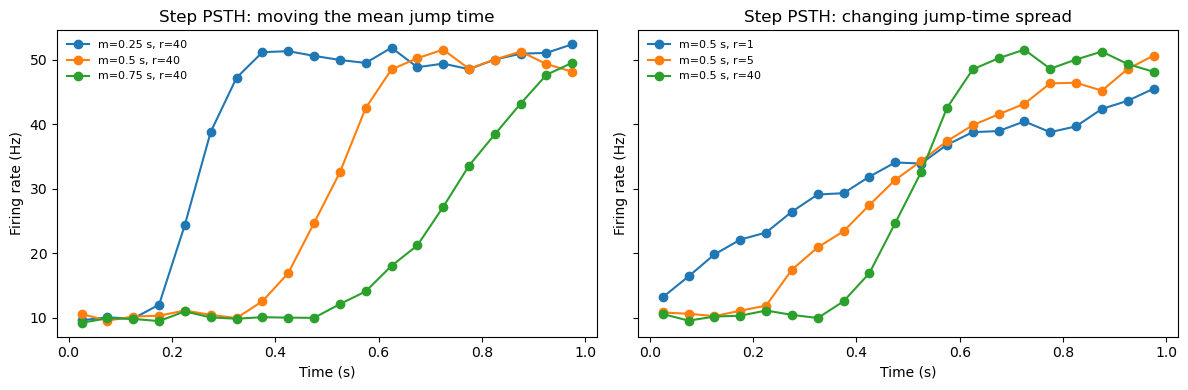

In [11]:
# Step-model parameter space.
# m controls when the average jump happens; r controls jump-time concentration.
np.random.seed(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

r = 40 # large for visualisation of m effect
for m in [T // 4, T // 2, 3 * T // 4]:
    np.random.seed(2)
    step = StepModel(m=m, r=r, x0=x0, Rh=Rh)
    spikes, _, _ = step.simulate(Ntrials=Ntrials, T=T)
    axes[0].plot(wide_centres, psth(spikes, wide_bins), marker="o", label=f"m={m/1000} s, r={r}")
axes[0].set_title("Step PSTH: moving the mean jump time")

for r in [1, 5, 40]:
    np.random.seed(2)
    step = StepModel(m=T // 2, r=r, x0=x0, Rh=Rh)
    spikes, _, _ = step.simulate(Ntrials=Ntrials, T=T)
    axes[1].plot(wide_centres, psth(spikes, wide_bins), marker="o", label=f"m={(T // 2)/1000} s, r={r}")
axes[1].set_title("Step PSTH: changing jump-time spread")

for ax in axes:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()


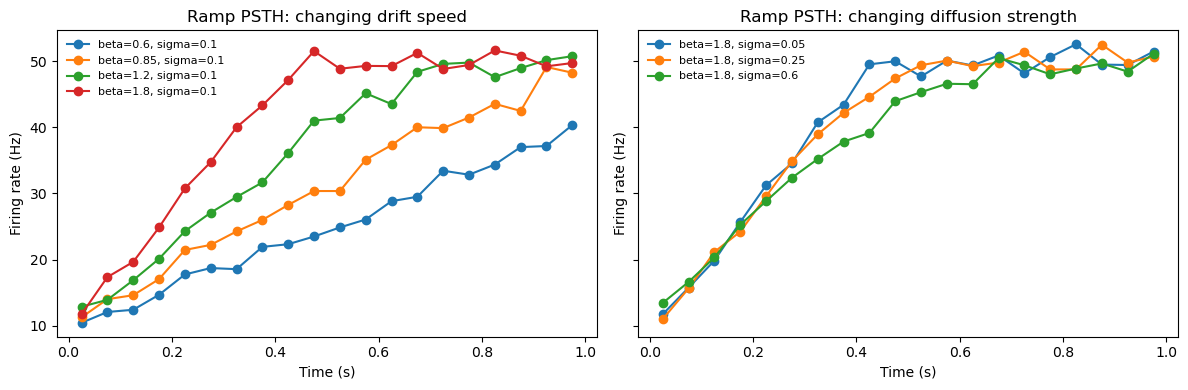

In [12]:
# Ramp-model parameter space.
# beta controls average ramp speed; sigma controls diffusion across trials.
np.random.seed(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sigma = 0.1  # small for visualisation of beta effect
for beta in [0.6, 0.85, 1.2, 1.8]:
    np.random.seed(2)
    ramp = RampModel(beta=beta, sigma=sigma, x0=x0, Rh=Rh)
    spikes, _, _ = ramp.simulate(Ntrials=Ntrials, T=T)
    axes[0].plot(wide_centres, psth(spikes, wide_bins), marker="o", label=f"beta={beta}, sigma={sigma}")
axes[0].set_title("Ramp PSTH: changing drift speed")

beta = 1.8  # large for visualisation of sigma effect
for sigma in [0.05, 0.25, 0.6]:
    np.random.seed(2)
    ramp = RampModel(beta=beta, sigma=sigma, x0=x0, Rh=Rh)
    spikes, _, _ = ramp.simulate(Ntrials=Ntrials, T=T)
    axes[1].plot(wide_centres, psth(spikes, wide_bins), marker="o", label=f"beta={beta}, sigma={sigma}")
axes[1].set_title("Ramp PSTH: changing diffusion strength")

for ax in axes:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()


Estimated power-law slope: -0.50


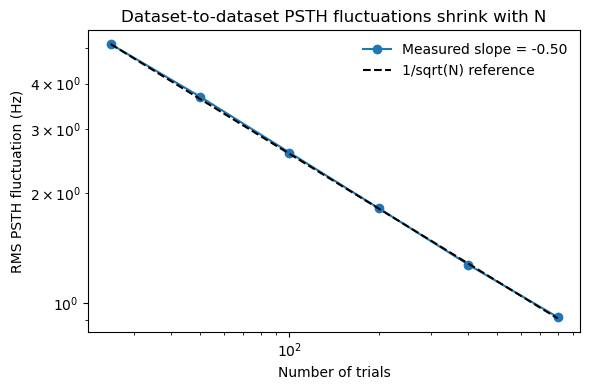

In [13]:
# Quantify how finite-trial PSTH fluctuations shrink as Ntrials increases.
# Each point is the RMS deviation of repeat PSTHs from their repeat-mean PSTH.
np.random.seed(2)

trial_counts = np.array([25, 50, 100, 200, 400, 800])
n_repeats = 80
fluctuation_rms = []
window = np.ones(window_steps)

for n in trial_counts:
    curves = []
    for _ in range(n_repeats):
        ramp = RampModel(beta=0.85, sigma=0.25, x0=x0, Rh=Rh)
        spikes, _, _ = ramp.simulate(Ntrials=n, T=T)
        raw_curve = psth(spikes, fine_bins)
        smoothed_curve = np.convolve(raw_curve, window, mode="same") / np.convolve(np.ones_like(raw_curve), window, mode="same")
        curves.append(smoothed_curve)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    fluctuation_rms.append(np.sqrt(np.mean((curves - mean_curve) ** 2)))

fluctuation_rms = np.array(fluctuation_rms)
slope, intercept = np.polyfit(np.log(trial_counts), np.log(fluctuation_rms), 1)
reference = fluctuation_rms[0] * (trial_counts / trial_counts[0]) ** (-0.5)

plt.figure(figsize=(6, 4))
plt.loglog(trial_counts, fluctuation_rms, "o-", label=f"Measured slope = {slope:.2f}")
plt.loglog(trial_counts, reference, "k--", label="1/sqrt(N) reference")
plt.xlabel("Number of trials")
plt.ylabel("RMS PSTH fluctuation (Hz)")
plt.title("Dataset-to-dataset PSTH fluctuations shrink with N")
plt.legend(frameon=False)
plt.tight_layout()

print(f"Estimated power-law slope: {slope:.2f}")


**Fluctuation scaling.** The PSTH is an average over independent trials. For a fixed time bin, averaging over $N_{\mathrm{trials}}$ trials divides the variance by $N_{\mathrm{trials}}$, so the standard deviation of PSTH fluctuations should scale like $1/\sqrt{N_{\mathrm{trials}}}$. The log-log plot above estimates this power law directly from repeated simulated datasets.

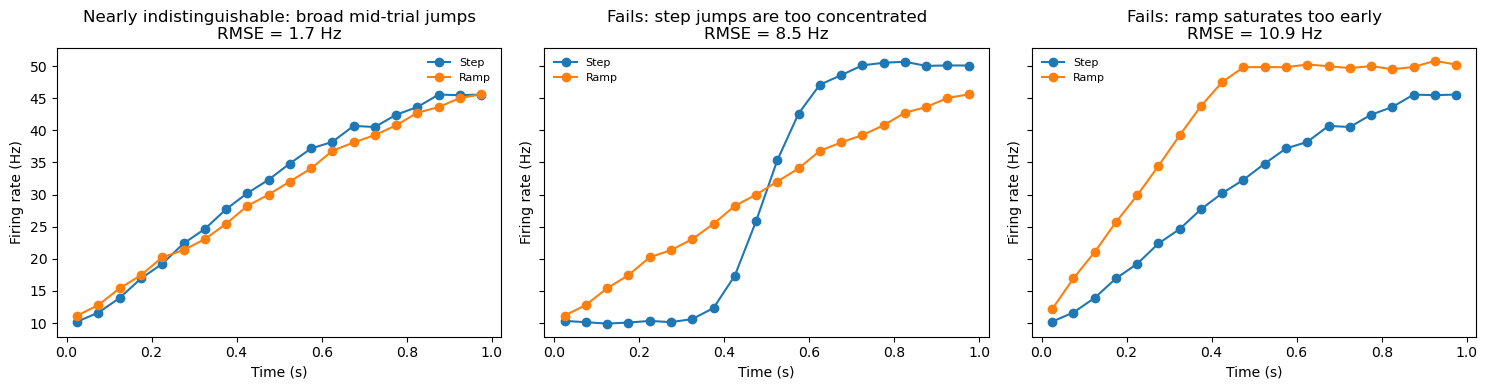

In [14]:
# Parameter regimes where step and ramp PSTHs are similar or clearly different.
np.random.seed(2)
Nhigh = 5000

comparisons = [
    (
        "Nearly indistinguishable: broad mid-trial jumps",
        StepModel(m=T//2, r=2, x0=x0, Rh=Rh),
        RampModel(beta=0.85, sigma=0.25, x0=x0, Rh=Rh),
    ),
    (
        "Fails: step jumps are too concentrated",
        StepModel(m=T//2, r=40, x0=x0, Rh=Rh),
        RampModel(beta=0.85, sigma=0.25, x0=x0, Rh=Rh),
    ),
    (
        "Fails: ramp saturates too early",
        StepModel(m=T//2, r=2, x0=x0, Rh=Rh),
        RampModel(beta=1.8, sigma=0.05, x0=x0, Rh=Rh),
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (title, step_model, ramp_model) in zip(axes, comparisons):
    np.random.seed(2)
    step_spikes, _, _ = step_model.simulate(Ntrials=Nhigh, T=T)
    np.random.seed(2)
    ramp_spikes, _, _ = ramp_model.simulate(Ntrials=Nhigh, T=T)
    step_curve = psth(step_spikes, wide_bins)
    ramp_curve = psth(ramp_spikes, wide_bins)
    rmse = np.sqrt(np.mean((step_curve - ramp_curve) ** 2))  # calculate basic rmse between two curves to quantify similarity

    ax.plot(wide_centres, step_curve, marker="o", label="Step")
    ax.plot(wide_centres, ramp_curve, marker="o", label="Ramp")
    ax.set_title(title + f"\nRMSE = {rmse:.1f} Hz")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()


**Parameter-space conclusion.** In the step model, $m/T$ sets where the PSTH rises and $r$ sets how sharp that rise is. Small-to-moderate `r` spreads jump times across trials, so the trial-averaged PSTH can look smoothly ramping even though each single trial is step-like. Large `r` makes the jump times concentrated and produces a sharp population step.

In the ramp model, `beta` mainly sets the average slope and time to threshold, while `sigma` spreads trajectories across trials. Step and ramp PSTHs are most similar when step jump times are broad and centred around the period over which the ramp rises. They differ strongly when step jumps are too concentrated, too early/late, or when the ramp either saturates very quickly or stays too flat/noisy over the trial.

### Task 1.3 - Fano factor

The PSTH is an example of a so-called first-order statistic, in that it is the average of spike counts, $n_t$, which is the first moment of their marginal distribution.

You can also evaluate higher order statistics, such as the variance of $n_t$ (across trials). (Instead of smoothing, for evaluating the variance use larger time bins -- e.g. 50 or 100 milliseconds). However, instead of directly plotting and exploring the variance, we will plot a more useful quantity: the **Fano factor**, 
which is the ratio of the variance of $n_t$ to its mean (obviously both evaluated in the same time bin). This quantity is 1 for the Poisson distribution (the default choice for the emission distribution of both models).

Evaluate and plot the Fano Factor as a function of time, and again investigate how it changes in different parameter regimes, and importantly whether and how it behaves differently in the two models.

#### Task 1.3 solution

The Fano factor is the ratio of the variance to the mean spike count in each time bin, evaluated across trials. Since both models emit Poisson spikes conditional on their latent rates, values above 1 reflect extra variability coming from uncertainty in the underlying latent state. This makes the Fano factor a useful second-order statistic for distinguishing models whose PSTHs can still look very similar.

Step Fano peak: 1.73
Ramp Fano peak: 1.13


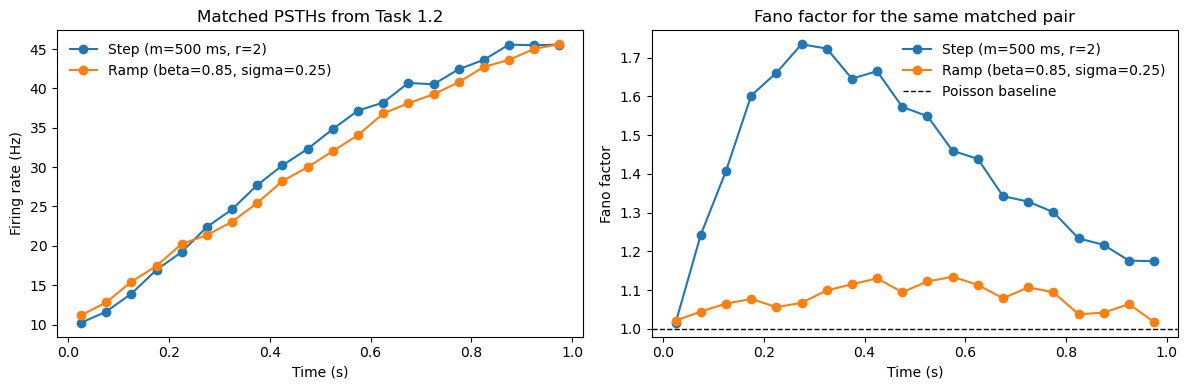

In [15]:
# Compare the matched-PSTH pair from Task 1.2 using both first- and second-order statistics.
np.random.seed(2)

def fano_factor(spikes, bins):
    counts = binned_counts(spikes, bins)
    mean_counts = counts.mean(axis=0)
    var_counts = counts.var(axis=0)
    return np.divide(var_counts, mean_counts, out=np.full_like(mean_counts, np.nan, dtype=float), where=mean_counts > 0)

Nhigh = 5000
step_bins = wide_bins
step_centres = wide_centres

m = T//2
r = 2

beta = 0.85
sigma = 0.25

step = StepModel(m=m, r=r, x0=x0, Rh=Rh)  # Params achieve similar 'jump' times as the ramp model from Task 1.2
ramp = RampModel(beta=beta, sigma=sigma, x0=x0, Rh=Rh)

np.random.seed(2)
step_spikes, _, _ = step.simulate(Ntrials=Nhigh, T=T)
np.random.seed(2)
ramp_spikes, _, _ = ramp.simulate(Ntrials=Nhigh, T=T)

step_psth = psth(step_spikes, step_bins)
ramp_psth = psth(ramp_spikes, step_bins)
step_fano = fano_factor(step_spikes, step_bins)
ramp_fano = fano_factor(ramp_spikes, step_bins)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(step_centres, step_psth, marker="o", label=f"Step (m={m} ms, r={r})")
axes[0].plot(step_centres, ramp_psth, marker="o", label=f"Ramp (beta={beta}, sigma={sigma})")
axes[0].set_title("Matched PSTHs from Task 1.2")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Firing rate (Hz)")
axes[0].legend(frameon=False)

axes[1].plot(step_centres, step_fano, marker="o", label=f"Step (m={m} ms, r={r})")
axes[1].plot(step_centres, ramp_fano, marker="o", label=f"Ramp (beta={beta}, sigma={sigma})")
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=1, label="Poisson baseline")
axes[1].set_title("Fano factor for the same matched pair")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Fano factor")
axes[1].legend(frameon=False)
plt.tight_layout()

print(f"Step Fano peak: {np.nanmax(step_fano):.2f}")
print(f"Ramp Fano peak: {np.nanmax(ramp_fano):.2f}")


**Matched-pair interpretation.** The PSTHs remain close because both parameter choices produce a similar rise in trial-averaged firing rate. The Fano factors are much less similar: the step model shows a stronger hump because different trials jump at different times, so bins near the jump region mix low-rate and high-rate trials and therefore have extra variance. The matched ramp remains much flatter because, for this parameter choice, the diffusion is only large enough to broaden the mean ramp slightly rather than to create such strong two-population mixing.

Note that relying on first order statistics for matching ramp and step models by first order statistics would be uneducated, as significant statistical differences arise already from the second order.

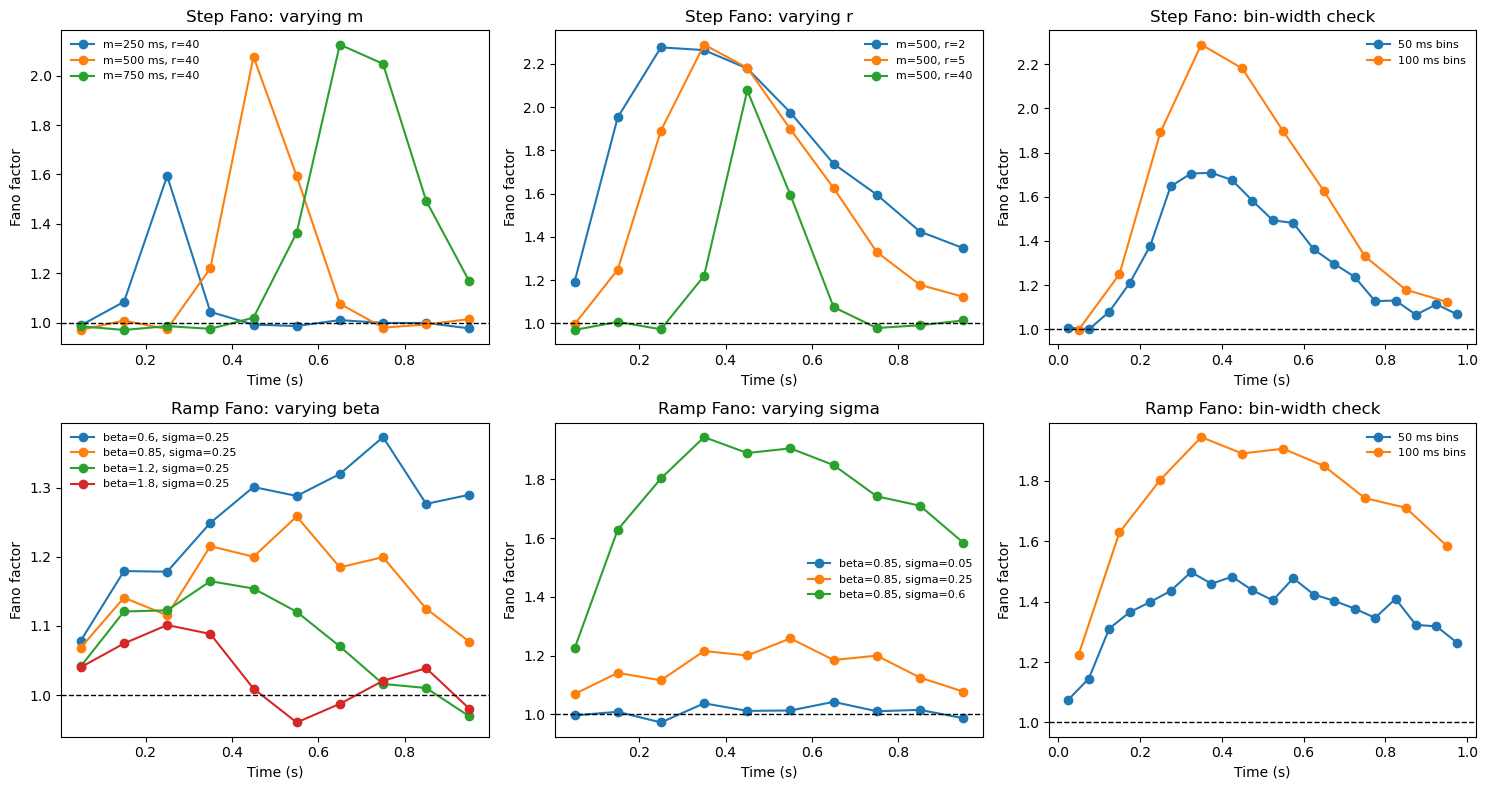

In [16]:
# Sweep the key parameters and compare 50 ms versus 100 ms bins.
np.random.seed(2)

Nhigh = 5000
bins_50 = np.arange(0, 1 + 0.05, 0.05)
centres_50 = 0.5 * (bins_50[:-1] + bins_50[1:])
bins_100 = np.arange(0, 1 + 0.1, 0.1)
centres_100 = 0.5 * (bins_100[:-1] + bins_100[1:])

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

r = 40  # fixed r for varying m in step model
for m in [T//4, T//2, 3*T//4]:
    np.random.seed(2)
    step = StepModel(m=m, r=r, x0=x0, Rh=Rh)
    spikes, _, _ = step.simulate(Ntrials=Nhigh, T=T)
    axes[0, 0].plot(centres_100, fano_factor(spikes, bins_100), marker="o", label=f"m={m} ms, r={r}")
axes[0, 0].axhline(1.0, color="k", linestyle="--", linewidth=1)
axes[0, 0].set_title("Step Fano: varying m")

for r in [2, 5, 40]:
    np.random.seed(2)
    step = StepModel(m=T//2, r=r, x0=x0, Rh=Rh)
    spikes, _, _ = step.simulate(Ntrials=Nhigh, T=T)
    axes[0, 1].plot(centres_100, fano_factor(spikes, bins_100), marker="o", label=f"m={T//2}, r={r}")
axes[0, 1].axhline(1.0, color="k", linestyle="--", linewidth=1)
axes[0, 1].set_title("Step Fano: varying r")

np.random.seed(2)
step = StepModel(m=T//2, r=5, x0=x0, Rh=Rh)
step_spikes, _, _ = step.simulate(Ntrials=Nhigh, T=T)
axes[0, 2].plot(centres_50, fano_factor(step_spikes, bins_50), marker="o", label="50 ms bins")
axes[0, 2].plot(centres_100, fano_factor(step_spikes, bins_100), marker="o", label="100 ms bins")
axes[0, 2].axhline(1.0, color="k", linestyle="--", linewidth=1)
axes[0, 2].set_title("Step Fano: bin-width check")

sigma = 0.25  # medium for visualisation of beta effect
for beta in [0.6, 0.85, 1.2, 1.8]:
    np.random.seed(2)
    ramp = RampModel(beta=beta, sigma=sigma, x0=x0, Rh=Rh)
    spikes, _, _ = ramp.simulate(Ntrials=Nhigh, T=T)
    axes[1, 0].plot(centres_100, fano_factor(spikes, bins_100), marker="o", label=f"beta={beta}, sigma={sigma}")
axes[1, 0].axhline(1.0, color="k", linestyle="--", linewidth=1)
axes[1, 0].set_title("Ramp Fano: varying beta")

for sigma in [0.05, 0.25, 0.6]:
    np.random.seed(2)
    ramp = RampModel(beta=0.85, sigma=sigma, x0=x0, Rh=Rh)
    spikes, _, _ = ramp.simulate(Ntrials=Nhigh, T=T)
    axes[1, 1].plot(centres_100, fano_factor(spikes, bins_100), marker="o", label=f"beta=0.85, sigma={sigma}")
axes[1, 1].axhline(1.0, color="k", linestyle="--", linewidth=1)
axes[1, 1].set_title("Ramp Fano: varying sigma")

np.random.seed(2)
ramp = RampModel(beta=0.85, sigma=0.6, x0=x0, Rh=Rh)
ramp_spikes, _, _ = ramp.simulate(Ntrials=Nhigh, T=T)
axes[1, 2].plot(centres_50, fano_factor(ramp_spikes, bins_50), marker="o", label="50 ms bins")
axes[1, 2].plot(centres_100, fano_factor(ramp_spikes, bins_100), marker="o", label="100 ms bins")
axes[1, 2].axhline(1.0, color="k", linestyle="--", linewidth=1)
axes[1, 2].set_title("Ramp Fano: bin-width check")

for ax in axes.flat:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fano factor")
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout()


**Sweep interpretation.** For the step model, changing `m` mainly shifts the Fano hump earlier or later in time, while changing `r` controls how broad that hump is. Small `r` spreads jump times over many trials and produces a broad elevation above 1, whereas large `r` concentrates the jump times and makes the late-trial Fano factor relax back toward 1 once almost all trials are in the same high-rate state.

For the ramp model, `beta` mainly changes how quickly the high-variance transient passes through the trial, while `sigma` is the strongest control over the overall size of the Fano factor. Low `sigma` keeps the ramp close to Poisson-like with Fano near 1, whereas larger `sigma` produces a broader and more elevated curve. Using 100 ms bins smooths the curves, but the qualitative contrast between the models remains the same.

We conclude that the larger bins captured more dramatic Fano variation, hence better capturing behviour for comparison.

### Task 1.4 - Further qualitative differences between the two models

(This is a more open-ended and less guided task compared to the previous ones. Use brainstorming in the group and come up with creative ideas to address this, working together.)

In this task you will explore an informal or relatively ad-hoc version of what we intend to do eventually using the systematic approach of Bayesian inference. The aim is to find an intelligent but ad-hoc (in the sense that it is not Bayesian and does not rely on the two models' likelihood function, but only relies on observed statistics) method for telling the two models apart, i.e. deciding which model generated a dataset, ***only*** based on the spike-train dataset that the method receives (obviously without cheating, i.e. without receiving the parameters or the label of the model that generated the dataset!).

Relying on the 1st and 2nd order statistics that you have explored (or other 2nd or higher order statistics you may come up it), construct a criterion (or multiple alternative criteria which you would then compare) for deciding between the two models. Try to come up with criteria that are relatively robust, i.e. are not handcrafted to tell the two models apart only for fixed choices (or very limited ranges) of parameters, but nevertheless can perform decently (though not magically!) when the two models are hard to distinguish based on the spike train statistics you explored in previous tasks.

Test your criterion by running it on several datasets generated by the two models. Use a fixed number of trials, **not more than 400**, per dataset. To generate a dataset, first sample the corresponding model parameters, uniformly at random, from the following ranges (for $\sigma$ sample $\ln \sigma$ uniformly and then exponentiate the sampled value): 

$$ \beta \in [0, 4], \quad
   \ln\sigma \in [\ln(0.04), \ln(4)], \quad
   r \in [0.5, 6], \quad
   m \in [T/4, 3T/4], \quad 
   x_0 \in [0, 0.5] $$

Quantify and report what percent of datasets generated (with different sampled parameters) from each model where classified correctly. 

#### Task 1.4 solution

A straightforward ad-hoc classifier is to look only for a clear peak in the Fano factor. Task 1.3 showed that step datasets often produce a pronounced hump because bins near the uncertain jump time mix low-rate and high-rate trials. Ramp datasets can still have elevated Fano factors, but they more often look flatter or rise toward one edge of the trial rather than producing a clean interior peak. I therefore classify a dataset as **step** only if its Fano curve has a sufficiently prominent interior peak; otherwise I classify it as **ramp**.

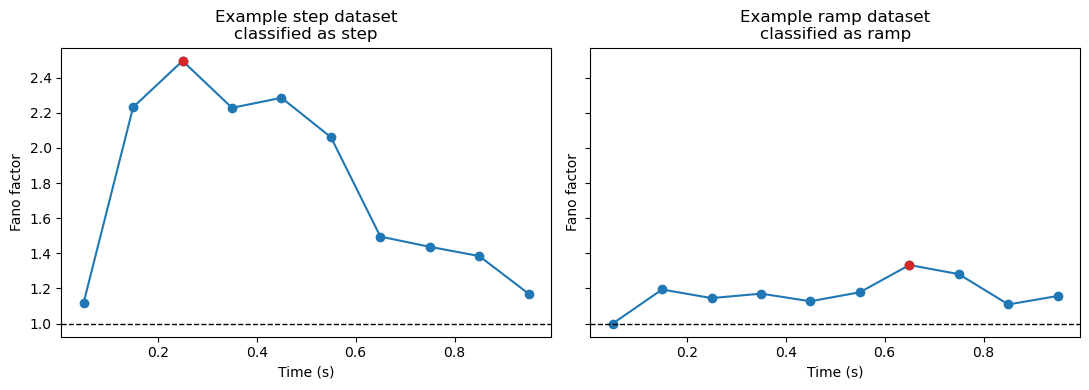

In [19]:
# Peak-based classifier using the Fano factor alone.
np.random.seed(2)

T = 100
Rh = 50
task14_bin_width = 0.1  # in s
task14_bins = np.arange(0, 1 + task14_bin_width, task14_bin_width)
task14_centres = 0.5 * (task14_bins[:-1] + task14_bins[1:])
task14_trials = 200
peak_prominence_threshold = 0.35
edge_gap_threshold = 0.20

def sample_step_params():
    m = int(round(np.random.uniform(T / 4, 3 * T / 4)))
    r = np.random.uniform(0.5, 6)
    x0_sample = np.random.uniform(0, 0.5)
    return m, r, x0_sample


def sample_ramp_params():
    beta = np.random.uniform(0, 4)
    sigma = np.exp(np.random.uniform(np.log(0.04), np.log(4)))
    x0_sample = np.random.uniform(0, 0.5)
    return beta, sigma, x0_sample


def peak_features(fano_curve):
    peak_index = int(np.nanargmax(fano_curve))
    peak_value = float(fano_curve[peak_index])
    edge_baseline = 0.5 * float(fano_curve[0] + fano_curve[-1])
    peak_prominence = peak_value - edge_baseline
    edge_gap = peak_value - max(float(fano_curve[0]), float(fano_curve[-1]))
    return peak_index, peak_value, peak_prominence, edge_gap


def classify_from_fano(fano_curve):
    peak_index, _, peak_prominence, edge_gap = peak_features(fano_curve)
    has_interior_peak = 0 < peak_index < len(fano_curve) - 1
    is_step = has_interior_peak and peak_prominence > peak_prominence_threshold and edge_gap > edge_gap_threshold
    return "step" if is_step else "ramp"


step_example = StepModel(m=T // 2, r=2, x0=0.2, Rh=Rh)
ramp_example = RampModel(beta=0.85, sigma=0.25, x0=0.2, Rh=Rh)

np.random.seed(2)
step_spikes, _, _ = step_example.simulate(Ntrials=task14_trials, T=T)
np.random.seed(2)
ramp_spikes, _, _ = ramp_example.simulate(Ntrials=task14_trials, T=T)

step_fano = fano_factor(step_spikes, task14_bins)
ramp_fano = fano_factor(ramp_spikes, task14_bins)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, curve, title in [
    (axes[0], step_fano, "Example step dataset"),
    (axes[1], ramp_fano, "Example ramp dataset"),
]:
    peak_index, peak_value, _, _ = peak_features(curve)
    predicted_label = classify_from_fano(curve)
    ax.plot(task14_centres, curve, marker="o")
    ax.axhline(1.0, color="k", linestyle="--", linewidth=1)
    ax.scatter(task14_centres[peak_index], peak_value, color="tab:red", zorder=3)
    ax.set_title(title + f"\nclassified as {predicted_label}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fano factor")

plt.tight_layout()


**Classifier rule.** I call a dataset **step-like** only if its Fano curve has a peak away from the edges of the trial, and if that peak rises clearly above the baseline set by the start and end of the curve. This is intentionally simple: the classifier is only looking for a pronounced Fano hump, because that is the most direct qualitative difference suggested by Tasks 1.2 and 1.3.

Step datasets classified correctly: 88.0%
Ramp datasets classified correctly: 68.0%
Thresholds used: prominence > 0.35 and edge gap > 0.2


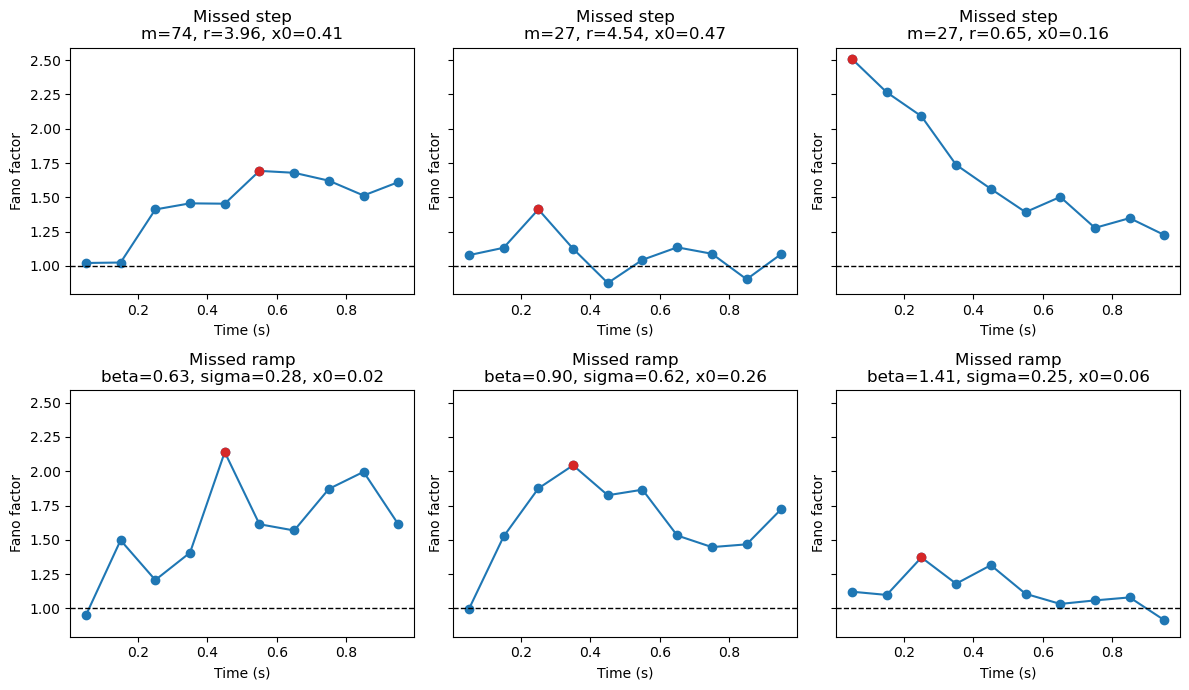

In [20]:
# Evaluate the peak-based classifier on many datasets from both models.
np.random.seed(2)

datasets_per_model = 100
step_correct = 0
ramp_correct = 0
step_examples = []
ramp_examples = []

for _ in range(datasets_per_model):
    m, r, x0_sample = sample_step_params()
    step = StepModel(m=m, r=r, x0=x0_sample, Rh=Rh)
    spikes, _, _ = step.simulate(Ntrials=task14_trials, T=T)
    fano_curve = fano_factor(spikes, task14_bins)
    predicted_label = classify_from_fano(fano_curve)
    if predicted_label == "step":
        step_correct += 1
    elif len(step_examples) < 3:
        step_examples.append((m, r, x0_sample, fano_curve))

for _ in range(datasets_per_model):
    beta, sigma, x0_sample = sample_ramp_params()
    ramp = RampModel(beta=beta, sigma=sigma, x0=x0_sample, Rh=Rh)
    spikes, _, _ = ramp.simulate(Ntrials=task14_trials, T=T)
    fano_curve = fano_factor(spikes, task14_bins)
    predicted_label = classify_from_fano(fano_curve)
    if predicted_label == "ramp":
        ramp_correct += 1
    elif len(ramp_examples) < 3:
        ramp_examples.append((beta, sigma, x0_sample, fano_curve))

step_accuracy = 100 * step_correct / datasets_per_model
ramp_accuracy = 100 * ramp_correct / datasets_per_model

print(f"Step datasets classified correctly: {step_accuracy:.1f}%")
print(f"Ramp datasets classified correctly: {ramp_accuracy:.1f}%")
print(f"Thresholds used: prominence > {peak_prominence_threshold} and edge gap > {edge_gap_threshold}")

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)

for ax, (m, r, x0_sample, curve) in zip(axes[0], step_examples):
    peak_index, peak_value, _, _ = peak_features(curve)
    ax.plot(task14_centres, curve, marker="o")
    ax.scatter(task14_centres[peak_index], peak_value, color="tab:red", zorder=3)
    ax.axhline(1.0, color="k", linestyle="--", linewidth=1)
    ax.set_title(f"Missed step\nm={m}, r={r:.2f}, x0={x0_sample:.2f}")

for ax, (beta, sigma, x0_sample, curve) in zip(axes[1], ramp_examples):
    peak_index, peak_value, _, _ = peak_features(curve)
    ax.plot(task14_centres, curve, marker="o")
    ax.scatter(task14_centres[peak_index], peak_value, color="tab:red", zorder=3)
    ax.axhline(1.0, color="k", linestyle="--", linewidth=1)
    ax.set_title(f"Missed ramp\nbeta={beta:.2f}, sigma={sigma:.2f}, x0={x0_sample:.2f}")

for ax in axes.flat:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fano factor")

plt.tight_layout()


**Task 1.4 conclusion.** A peak-based Fano classifier is simple and captures an important qualitative difference between the two models: step datasets often produce a pronounced interior Fano hump, while ramp datasets are more likely to look flatter or edge-dominated. This classifier is clearly not perfect, and the misclassified examples show why. Some step datasets have weak or very broad peaks, while some ramp datasets with large diffusion can also produce strong Fano peaks. Even so, the method gives a transparent ad-hoc rule that uses only observable spike-train statistics, as requested.

# Week 2: Latent variable inference

In [2]:
from scipy.stats import nbinom
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

import inference
from models import StepModel, RampModel

In Week 2, your task is to formulate the two models as (time-homogeneous) **Hidden Markov Models (HMM)** with *discrete* states. To recap, a HMM is described by latent variables that are (1) temporal/sequential and (2) form a **Markov chain (MC)**. If we denote these variable at time step $t$ by $x_t$, the Markovian property means that conditioned on $x_t$, all future states $(x_{t+1}, x_{t+2}, \ldots)$ are independent of states at times before $t$. Colloquially, conditioned on the present, the future is independent of the past.

In an HMM, the Markovian state variables are not directly observed. Instead at each time, we observe an observed variable, $n_t$, which only depends of the Markov state, $x_t$, at the same time step. For us this dependence is given by the Poisson distribution describing the spike emissions, conditioned on the rates, with the latter being determined by $x_t$ (in other words, the rate at time $t$ is a deterministic instantaneous functions of $x_t$). Figure 2 shows the graphical model for the HMM, with such Poisson observation (aka emission) distributions.  

Here, we aim to design Markov chains with discrete states to approximate the behavior of the latent variables of the step and ramp models. In the case of the step model, the discretization is actually exact, as the model really just has two levels of rates (although we will see that the correspondence between Markov states and possible firing rate levels is rather complicated). It is for the ramp model that a discretization will be an approximation (since in the original formulation of this model, the state variables, $x_t$, are continuous variables). 

The reason for formulating the models as discrete state HMMs is that in this case we can use the powerful and efficient 
[forward-backward algorithm](https://en.wikipedia.org/wiki/Forward%E2%80%93backward_algorithm) to calculate
1. the Bayesian *posterior* estimate (the posterior mean) of the state variables, $x_t$, given the observations, $n_t$, and
2. the model likelihood function, $P(n_{1:t}|\Theta, \mathcal{M})$, i.e. the probability of the observed spike train conditioned on the model parameters $\Theta$ (for each model $\mathcal{M} = $ ramp or step).


<img src="figs/HMM_graph.png" width=600/>





### Task 2.1:  Forming an HMM approximation to the ramp model

$\newcommand{\T}{\mathcal{T}}$
The state variable of the (original) ramp model is continuous and, because the update rule $x_{t+1} = x_t + \beta dt + \sigma\sqrt{dt}\epsilon_t$ involves the Gaussian variables $\epsilon_t$, their transition probabilities $P(x_{t+1}| x_{t})$ are Gaussian (with mean and variance possibly depending on $x_t$, as well as the model parameters). Your first sub-task is to work out this distribution.

First, we will now assume $x_t$ does not go below 0. Thus if $x_t$ is currently zero, and the proposed change according to normal update rule of $x_t$ is negative, $x_t$ will remain at 0; only if the proposed change is positive it is actually implemented. (Note that this is a redefinition of the model's latent variables, it does not affect the behaviour of rates and thus spikes; and thus it does really change the model.)

Next, we will approximate $x_t$ by assuming it takes values on a regular grid of $K$ points going from 0 to 1, inclusive of both ends. Let's use $K=50$ or $K=100$. These $K$ points form the discrete states of the discrete-state HMM that approximates the original ramp model. We will denote these states by their index $s$ going from 0 to $K-1$.
The corresponding value of $x_t$ is then given by 

$$ x_t = \frac{s_t}{K-1} \qquad \text{where} \quad s_t \in \{0, \ldots, K - 1\}$$

By evaluating the relevant probabilities, based on the Gaussian distribution you derived above, form the transition matrix for the Markov chain, defined as 

$$
\T_{s,s'} = P(s_{t+1}= s'| s_{t}= s)
$$

Note that the state *transitioned to* (i.e. the one at $t+1$) is the column index of the matrix. Thus the rows of $\T$ have to sum up to 1. You may need to (and it certainly would not hurt to) **enforce this constraint by hand** after constructing the (initial) matrix using the evaluated Gaussian probabilities.

Also note transitions out of the last state $s = K-1$ need special consideration, as according to the original model, once the variable $x$ reaches 1, it stays there. 

Next, you will need to form the initial state distribution, $\pi$, as an array of $K$ values (summing to 1!) giving the probabilities of different possibilities of $s_0$. This should approximate the equation $x[0] = x_0 + \sigma\sqrt{dt} \epsilon_0$.

Once the transition matrix $\T$ and initial state distribution $\pi$ are formed, we can simulate the chain. In order to do this, you will first draw $s_0$ from the initial state distribution, then successively sample from the appropriate distribution according to the transition matrix $\T$ (and depending on the current state $s_t$). To sample the discrete (integer) $s$ from a distribution over its $K$ possibilities, you can use `np.random.choice`.

For different choices of the model parameters, $\beta$, $\sigma$ and $x_0$, simulate several trials of this chain and (after appropriate rescaling) plot the trajectories $x_t$. Based on the trajectory $x_t$, calculate the firing rate trajectory $r_t$. Compare these rate trajectories with corresponding simulated rate trajectories of the original (continuous state) ramp model, to make sure your implementation is accurate *enough*. 

Note that for small enough values of $\sigma$ the Markov chain approximation will produce trajectories that get stuck at the inital state. Why is this? For the case $\beta=0$, estimate, solely in terms of $K$ and $T$ (or $dt$), the *order of magnitude* (or "scaling") of the value of $\sigma$  (up to a constant of proportionality) below which trajectories tend to get stuck. In the rest of the project use values of $\sigma$ above this value, unless indicated otherwise (e.g. when use of specific ranges for parameters are instructed).

**Note:** Note also that if you use values of $\sigma$ that are too small, and depending on your code for constructing the transition matrix, your code for generating $\T$ or $\pi$ may run into numerical truncation issues resulting in `NaN` values. Something that could help is implementing things first in terms of log-probabilities, using the numerically stable function `scipy.special.logsumexp` in the normalization step (when you normalize rows of $\T$ or the vector $\pi$), and only in the end exponentiating to obtain the actual $\T$ or $\pi$. 

#### Task 2.1 Solution

Notes and Planning

By inspection of the autoregressive process given in the question
$$
E[x_{t+1} | x_{t}] = x_t + \beta dt
$$
$$
\mathrm{Var}[x_{t+1} | x_{t}] = E[(x_{t+1} - E[x_{t+1}])^2 \vert x_t] = E[\sigma^2dt\epsilon_t^2] = \sigma^2dt
$$
Hence the Gaussian distribution is as follows
$$
P(x_{t+1}\vert x_t) = \mathcal{N}(x_{t+1} ; x_t + \beta dt , \sigma^2 dt)
$$
Beware that this is the uncontrained solution, we must take `x_{t+1} = Max(0, x_{t+1})` as output from the above, since we require the latent to be non-negative for the ramp model.

The discretise `xt` by considering K discretised states between [0,1] inclusive, use K = 100 for higher accuracy but fall back on 50 if compute is too expensive. Define the states st. 
$$
x_t = \frac{s_t}{K-1},\ \mathrm{so}\ s_t = (K-1)x_t
$$

Consider building the transition matrix where $\mathcal{T}_{ij} = p(s_{t+1} = i\vert s_t = j)$ so from row to col transitions i.e. working with column vectors for written linear algebra.

Considering we need the state the remain at 1 at the end, I believe assigning the corresponding s_t approximation from x_t should be upper bound inclusive. So round up $(K-1)x_t$ for the corresponding $s_t$ integer, care needs to be taken for the final state as x_t. Consider `st = Min(st, 1)` to enforce upperbound.

Transition matirx requires the interval's of xt corresponding to each st. From the definition of st, actually change previous suggestion of rounding up to rounding down, since we only want the final state to be when xt has reached one, not before. So consider casting `st = int( xt (K-1) )` which should round down to integer.

In developing the code, found that there isn't a reason to explicity discretise our x or s variables, instead only using the rounding logic for finding intervals to be used the calculate transition probabilities.

In [3]:
def build_ramp_hmm(K=100, beta=0.2, sigma=0.1, T=100, x0=0.3):
    """
    Build the discrete-state HMM approximation for the ramp model.

    Returns
    -----
    Ps : ndarray, shape (K, K)
        Transition matrix with rows summing to 1.
    pi : ndarray, shape (K,)
        Initial state distribution summing to 1.
    """
    dt = 1/T
    
    # Transition matrix
    Ps = np.zeros((K, K))

    for s in range(K-1):  # don't compute for top state s=K-1 since it's absorbing
        x = s / (K - 1)
        mean = x + beta * dt
        std = sigma * np.sqrt(dt)

        # interior bins

        for sp in range(K):  # don't compute for top state sp=K-1 since it's absorbing

            a = -np.inf if sp == 0 else (sp - 1/2) / (K - 1)
            b = np.inf if sp == K - 1 else (sp + 1/2) / (K - 1)
            Ps[s, sp] = norm.cdf((b - mean) / std) - norm.cdf((a - mean) / std)  # probability of starting in s, transitioning to sp

        # enforce row normalisation, check without for correct method
        Ps[s] = Ps[s] / Ps[s].sum()

    # top state absorbing
    Ps[K - 1, K - 1] = 1.0
    
    # Initial state distribution
    pi = np.zeros(K)
    mean = x0
    std0 = sigma * np.sqrt(dt)

    for s in range(K):
        a = -np.inf if s == 0 else (s - 1/2) / (K - 1)
        b = np.inf if s == K - 1 else (s + 1/2) / (K - 1)
        pi[s] = norm.cdf((b - mean) / std0) - norm.cdf((a - mean) / std0)

    pi = pi / pi.sum()

    # Testing for NaN values
    assert not np.any(np.isnan(Ps)), "Transition matrix contains NaN values"
    assert not np.any(np.isnan(pi)), "Initial state distribution contains NaN values"

    return Ps, pi


# # Example usage
# Ps, pi = build_ramp_hmm(K=5, beta=0.2, sigma=0.1, dt=0.01, x0=0.3)
# print(f"Transition matrix Ps:\n{Ps}")
# print(f"Rows of Ps sum to: {Ps.sum(axis=1)}")
# print(f"Initial state distribution pi: \n{pi}")

# assert np.allclose(Ps.sum(axis=1), 1), "Transition matrix rows do not sum to 1"
# print(f"Row Sums of Ps: \n{Ps.sum(axis=1)}")
# assert np.isclose(pi.sum(), 1), "Initial state distribution does not sum to 1"
# print("Initial State Distribution: ", pi)

In [4]:
def simulate_discrete_ramp(T, pi, Ps, n_trials=5):
    """
    Simulate n_trials trajectories from the discrete-state HMM ramp model.
    
    Returns
    -----
    states : ndarray, shape (n_trials, T)
        The state trajectories.
    xs  : ndarray, shape (n_trials, T)
        The state trajectories normalized to [0, 1].
    rates : ndarray, shape (n_trials, T)
        The firing rates computed as Rh * max(0, xs).
    spikes  : ndarray, shape (n_trials, T)
        The spike counts generated as Poisson samples from the rates.
    """
    dt = 1/T
    K = len(pi)  # Find number of states from length of initial distribution
    states = np.zeros((n_trials, T), dtype=int)  # (n_trials, T), initalise state array

    for trial in range(n_trials):
        s = np.random.choice(np.arange(K), p=pi)  # sample initial state from pi
        states[trial, 0] = s

        for t in range(1, T):
            s = np.random.choice(np.arange(K), p=Ps[states[trial, t-1]])
            states[trial, t] = s
            
    xs = states / (K - 1)  # (n_trials, T)
    rates = Rh * np.maximum(0, xs)  # (n_trials, T)
    spikes = np.random.poisson(rates * dt)  # (n_trials, T)
    
    return states, xs, rates, spikes

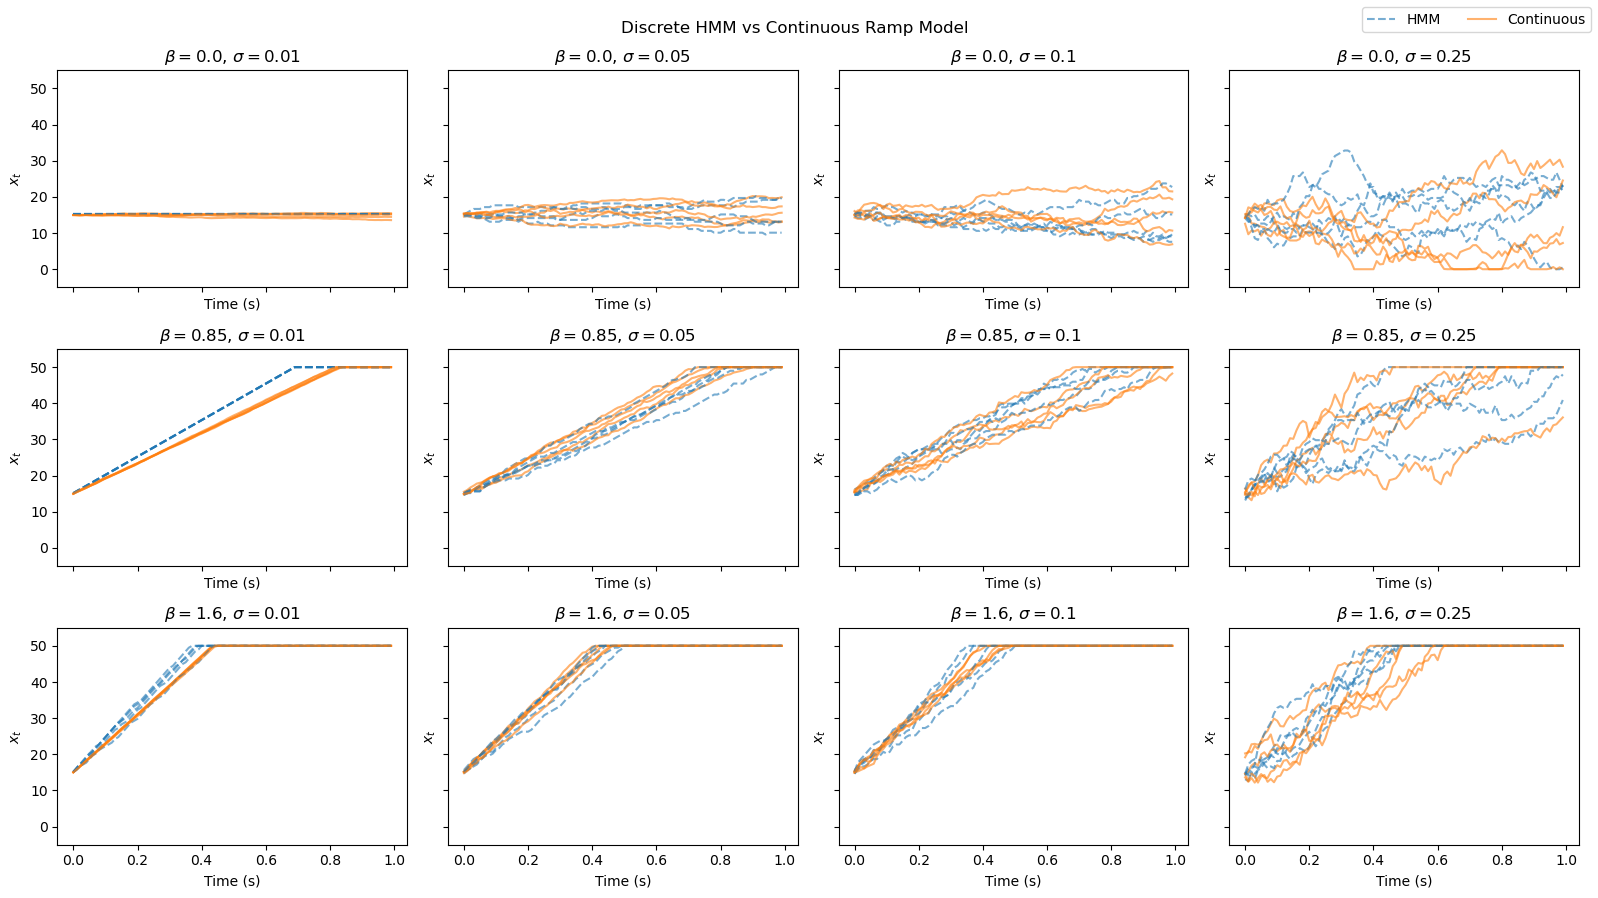

In [27]:
def plot_ramp_hmm_vs_continuous(
    ax=None,
    K=100, beta=0.85, sigma=0.25, x0=0.3,
    T=1000, n_trials=5, Rh=50
):
    dt = 1 / T

    Ps, pi = build_ramp_hmm(K=K, beta=beta, sigma=sigma, x0=x0)
    _, hmm_xs, hmm_rates, _ = simulate_discrete_ramp(T, pi, Ps, n_trials=n_trials)

    ramp = RampModel(beta=beta, sigma=sigma, x0=x0, Rh=Rh)
    _, cont_xs, cont_rates = ramp.simulate(Ntrials=n_trials, T=T, get_rate = True)

    time = np.arange(T) / T

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    for i in range(n_trials):
        ax.plot(time, hmm_rates[i], '--', color='tab:blue', alpha=0.6,
                label='HMM' if i == 0 else None)
        ax.plot(time, cont_rates[i], '-', color='tab:orange', alpha=0.6,
                label='Continuous' if i == 0 else None)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('$x_t$')
    ax.set_title(f'$\\beta={beta}$, $\\sigma={sigma}$')
    ax.set_ylim(-Rh/10, Rh + Rh/10)

    return ax

# Sweep variables of both discrete HMM and continuous ramp to compare trajectories
betas = [0.0, 0.85, 1.6]
sigmas = [1e-2, 0.05, 0.1, 0.25]

K = 100
x0 = 0.3
T = 100
n_trials = 5
Rh = 50

fig, axes = plt.subplots(
    nrows=len(betas),
    ncols=len(sigmas),
    figsize=(4 * len(sigmas), 3 * len(betas)),
    sharex=True,
    sharey=True
)

for i, beta in enumerate(betas):
    for j, sigma in enumerate(sigmas):
        ax = axes[i, j]
        plot_ramp_hmm_vs_continuous(
            ax=ax,
            beta=beta,
            sigma=sigma,
            x0=x0,
            T=T,
            n_trials=n_trials,
            Rh=Rh
        )

# One shared legend for the whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2)

fig.suptitle('Discrete HMM vs Continuous Ramp Model')
plt.tight_layout()
plt.show()

        


### Task 2.2:  Forming an HMM approximation to the step model

Intuitively, given its discrete (binary) rate levels, the step model can actually be exactly formulated as a discrete state HMM.

First, implement a *time-homogeneous* Markov chain representing the step state with two states. How would you choose the transition probabilities? Hint: think of the 
parameter $p$ of the Negative Binomial distribution (see the Wikipedia article), which in terms of $m$ and $r$ is given by $r/(m+r)$.

Simulate the Markov chain for several trials and plot the corresponding $x_t$ trajectories. 

Also evaluate the jump times (time-steps) and make histograms of these jump times. How do the histograms appear? Do they resemble any of the histograms of jump times (i.e. histograms for different values of $m$ and $r$) that  you made in Week 1? 

What do you think is wrong with the 2-state Markov chain approximation to the step model [**§**]?

Read about the [Negative Binomial distribution](https://en.wikipedia.org/wiki/Negative_binomial_distribution) and its "meaning" (*for the case of positive integer $r$*), to get clues for constucting an exact Markov Chain formulation of the step model (Hint: use $r + 1$ states!) [**§§**].

Again, simulate several trials of this new chain, plot state trajectories, and form histograms of jump times for different values of $r$. How do these compare with the histograms you obtained in Week 1 for jump times of the original step model?

----

**§:** An exact formulation of the step model is possible as a *time-inhomogenous* 2-state Markov chain (MC). You can experiment with that of course (this is optional). However, we will be using a time-homogenous HMM, and so in the above sub-task I am asking you to construct a time-homogenous Markov chain. If you did implement a time-inhomogeneous MC formulation, feel free to write about it in your final report. But make sure you do investigate the time-homogeneous version (which is in general not a correct formulation of the original model) as well, and answer the questions for that (too).

**§§:** The suggested MC implementation of the step model will differ from the Week 1 step model, in which step time had the distribution $\mathrm{NB}(\tau | m, r)$ by a time shift by $r$ time-steps.

In [5]:
def simulate_discrete_step(Ps, pi, T=100, x0=0.3, Rh=50, n_trials=5):
    """
    Simulate trajectories from a discrete-state step HMM.

    Works for:
    1. 2-state time-homogeneous model: Ps.shape = (2, 2)
    2. r+1-state time-homogeneous model: Ps.shape = (r+1, r+1)
    3. 2-state time-inhomogeneous model: Ps.shape = (T-1, 2, 2)

    Convention:
    - Final state K-1 is the post-jump/high-rate state.
    - All earlier states emit the low firing rate x0 * Rh.
    - Jump time is the first time index at which state K-1 is reached.
    - If no jump occurs during the trial, jump time is set to T.

    Returns
    -------
    states : ndarray, shape (n_trials, T)
        Simulated hidden-state trajectories.
    xs : ndarray, shape (n_trials, T)
        State trajectories normalized to [0, 1].
    rates : ndarray, shape (n_trials, T)
        Firing-rate trajectories.
    spikes : ndarray, shape (n_trials, T)
        Simulated spike trains.
    jumps : ndarray, shape (n_trials,)
        Jump time for each trial.
    """
    # Define params
    dt = 1/T
    K = len(pi)
    jump_state = K - 1  # final state is the jump/high-rate state

    # Basic checks
    assert np.isclose(pi.sum(), 1), "Initial distribution pi must sum to 1"
    assert np.all(pi >= 0), "Initial distribution pi contains negative entries"

    # Decide if homogeneous or inhomogeneous model
    if Ps.ndim == 2:
        # Time-homogeneous case: same transition matrix at every time step
        assert Ps.shape == (K, K), "For homogeneous model, Ps must have shape (K, K)"
        assert np.allclose(Ps.sum(axis=1), 1), "Transition rows must sum to 1"
        homogeneous = True

    elif Ps.ndim == 3:
        # Time-inhomogeneous case: one transition matrix for each t-1 -> t
        assert Ps.shape == (T - 1, K, K), "For inhomogeneous model, Ps must have shape (T-1, K, K)"
        assert np.allclose(Ps.sum(axis=2), 1), "Each transition row must sum to 1"
        homogeneous = False

    else:
        raise ValueError("Ps must have shape (K, K) or (T-1, K, K)")

    states = np.zeros((n_trials, T), dtype=int)  # (n_trials, T)
    jumps = np.full(n_trials, T, dtype=int)  # (n_trials, ), initialize jump times to T (indicating no jump)

    for trial in range(n_trials):
        # Initial state
        states[trial, 0] = np.random.choice(np.arange(K), p=pi)

        if states[trial, 0] == jump_state:
            jumps[trial] = 0

        # Evolve state sequence
        for t in range(1, T):
            current_state = states[trial, t - 1]

            if homogeneous:
                probs = Ps[current_state]
            else:
                probs = Ps[t - 1, current_state]

            states[trial, t] = np.random.choice(np.arange(K), p=probs)

            if states[trial, t] == jump_state and jumps[trial] == T:
                jumps[trial] = t

    xs = np.where(states == jump_state, 1.0, x0)  # (n_trials, T)
    rates = np.where(states == jump_state, Rh, x0 * Rh)  # (n_trials, T)
    spikes = np.random.poisson(rates * dt)  # (n_trials, T)

    return states, xs, rates, spikes, jumps


In [6]:
def build_step_hmm_2states(m=T//2, r=20):
    """
    Build the time-homogenous discrete-state HMM approximation for the step model.

    Returns
    -----
    Ps : ndarray, shape (2, 2)
        Transition matrix with rows summing to 1.
    pi : ndarray, shape (2,)
        Initial state distribution summing to 1.
    p  : float
        Probability of jumping at each time step, used for testing and interpretation.
    """

    # Transition matrix
    p = r / (m + r) # probability of jumping at each time step
    Ps = np.array([[1-p, p],[0, 1]])

    # Initial state distribution
    pi = np.array([1-p, p])

    return Ps, pi, p


# Example usage
Ps, pi, _ = build_step_hmm_2states(m=T//2, r=20)
assert np.allclose(Ps.sum(axis=1), 1), "Transition matrix rows do not sum to 1"
print(f"Row Sums of Ps: \n{Ps.sum(axis=1)}")
assert np.isclose(pi.sum(), 1), "Initial state distribution does not sum to 1"
print("Initial State Distribution: ", pi)

Row Sums of Ps: 
[1. 1.]
Initial State Distribution:  [0.71428571 0.28571429]


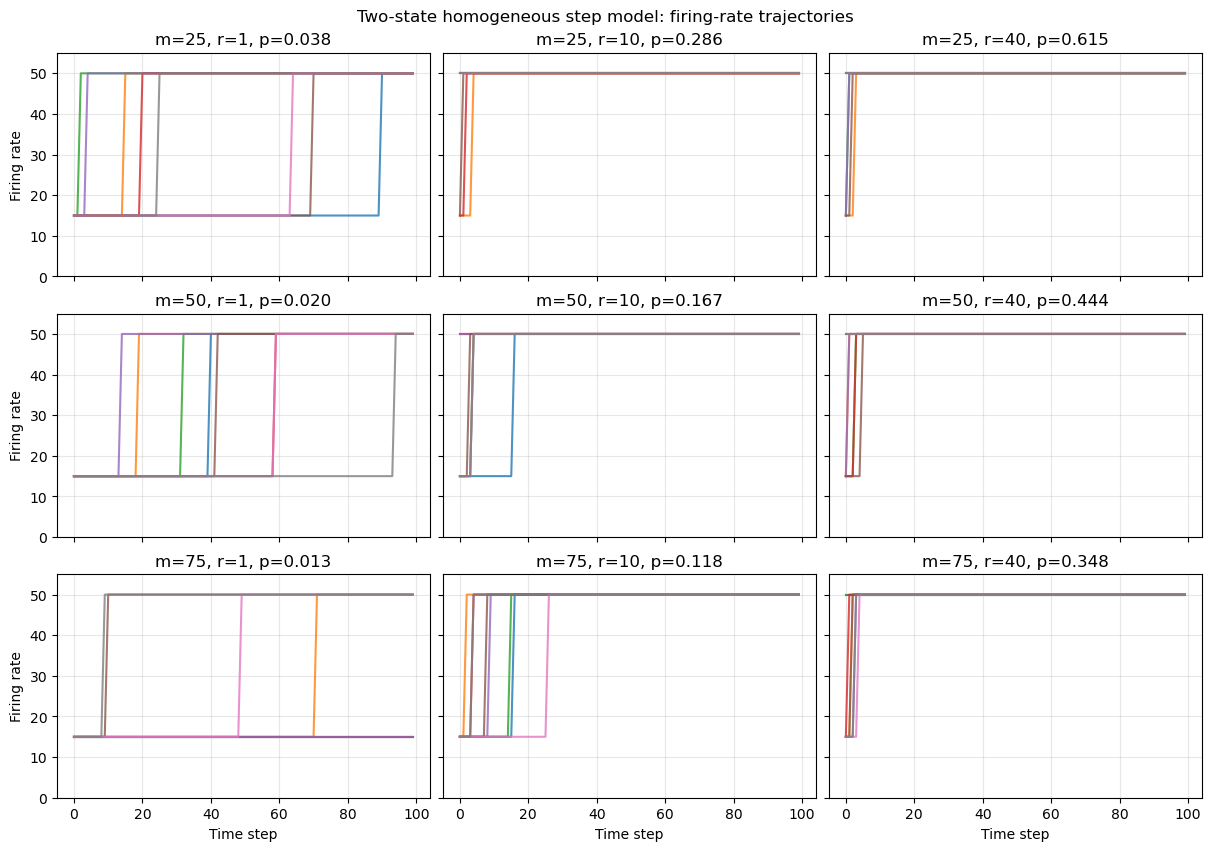

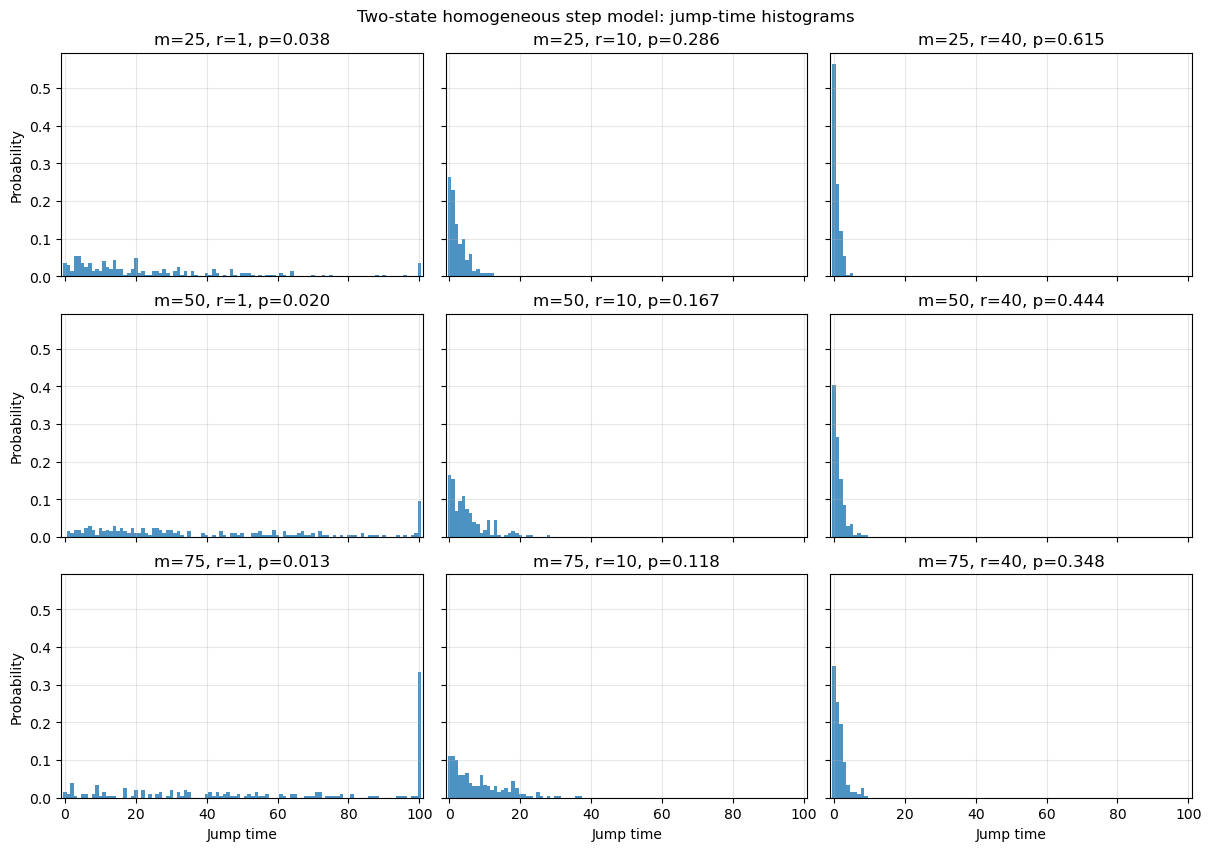

In [25]:
# Sweep over separate m and r arrays
T = 100
m_values = [T//4, T//2, 3* T//4]
r_values = [1, 10, 40]

n_trials = 200
n_plot_trials = 8
x0 = 0.3
Rh = 50

# Store results so the same simulations are used for both figures
results = {}

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        Ps, pi, p = build_step_hmm_2states(m=m, r=r)

        states, _, rates, _, jumps = simulate_discrete_step(
            Ps, pi,
            T=T,
            x0=x0,
            Rh=Rh,
            n_trials=n_trials
        )

        results[(m, r)] = {
            "p": p,
            "jumps": jumps,
            "rates": rates
        }

fig, axes = plt.subplots(
    len(m_values),
    len(r_values),
    figsize=(4 * len(r_values), 2.8 * len(m_values)),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        ax = axes[i, j]
        rates = results[(m, r)]["rates"]
        p = results[(m, r)]["p"]

        for trial in range(n_plot_trials):
            ax.plot(rates[trial], alpha=0.8)

        ax.set_title(f"m={m}, r={r}, p={p:.3f}")
        ax.set_ylim(0, 1.1 * Rh)
        ax.grid(alpha=0.3)

        if i == len(m_values) - 1:
            ax.set_xlabel("Time step")
        if j == 0:
            ax.set_ylabel("Firing rate")

fig.suptitle("Two-state homogeneous step model: firing-rate trajectories")
plt.show()

fig, axes = plt.subplots(
    len(m_values),
    len(r_values),
    figsize=(4 * len(r_values), 2.8 * len(m_values)),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        ax = axes[i, j]
        jumps = results[(m, r)]["jumps"]
        p = results[(m, r)]["p"]

        ax.hist(
            jumps,
            bins=np.arange(T + 2) - 0.5,
            density=True,
            alpha=0.8
        )

        ax.set_title(f"m={m}, r={r}, p={p:.3f}")
        ax.set_xlim(-1, T + 1)
        ax.grid(alpha=0.3)

        if i == len(m_values) - 1:
            ax.set_xlabel("Jump time")
        if j == 0:
            ax.set_ylabel("Probability")

fig.suptitle("Two-state homogeneous step model: jump-time histograms")
plt.show()

Recongise that modelling the process as i.i.d bernoulli can only capture the model dynamics for $r \le 1$. It cannot capture the suitable waiting shape otherwise, as clearly recognised from large r examples.

The two-state homogeneous Markov chain produces geometrically distributed jump times with a visible censoring mass at T for trials that do not jump. This is consistent with the implemented transition matrix. However, it does not reproduce the original Negative Binomial step-time distribution for $r>1$, because the two-state chain waits for the first success rather than the r-th success.

In [7]:
def build_step_hmm_rstates(m=T//2, r=20):
    """
    Build the time-homogenous discrete-state HMM approximation for the step model.

    Returns
    -----
    Ps : ndarray, shape (2, 2)
        Transition matrix with rows summing to 1.
    pi : ndarray, shape (r+1,)
        Initial state distribution summing to 1.
    p  : float
        Probability of jumping at each time step, used for testing and interpretation.
    """

    # Transition matrix
    p = r / (m + r) # probability of jumping at each time step

    #special case for r=1
    if r == 1:
        Ps = np.array([[1-p, p], [0, 1]])  # if r=1, it's just one state with no jumps
        pi = np.array([1-p, p])
        return Ps, pi, p
    
    Ps = np.zeros((r+1, r+1))
    for i in range(r):
        Ps[i][i] = 1-p
        Ps[i][i+1] = p
    Ps[r][r] = 1.0  # absorbing state

    # Initial state distribution
    pi = np.zeros(r+1)
    pi[0] = 1-p
    pi[1] = p

    return Ps, pi, p


# # Example usage
# Ps, pi, _ = build_step_hmm_rstates(m=T//2, r=20)
# assert np.allclose(Ps.sum(axis=1), 1), "Transition matrix rows do not sum to 1"
# print(f"Row Sums of Ps: \n{Ps.sum(axis=1)}")
# assert np.isclose(pi.sum(), 1), "Initial state distribution does not sum to 1"
# print("Initial State Distribution: ", pi)

# # Example usage of simulation
# r = 40
# Ps, pi, p = build_step_hmm_rstates(m=T//2, r=r)
# jumps, rates, states = simulate_discrete_step(Ps, pi, T=T, x0=0.3, Rh=50, n_trials=5)
# print("Jump times for each trial: ", jumps)

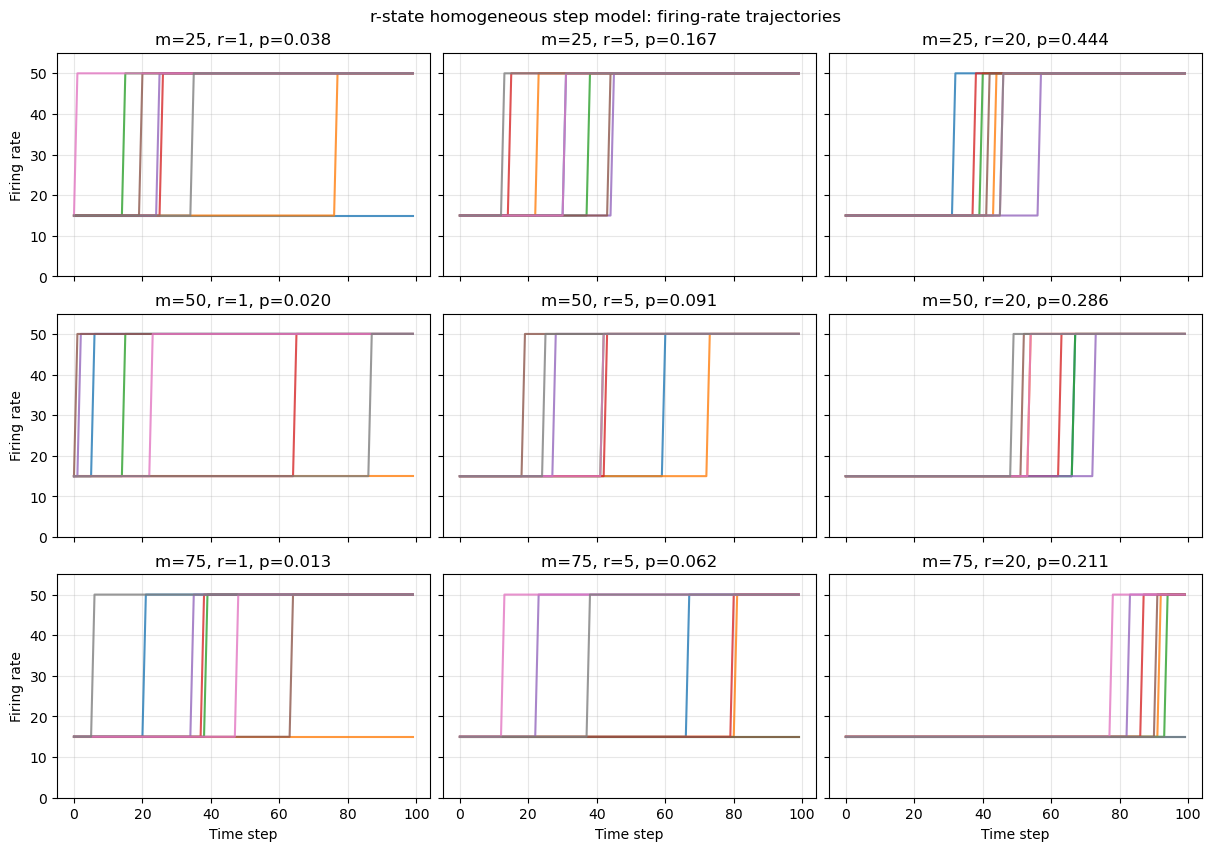

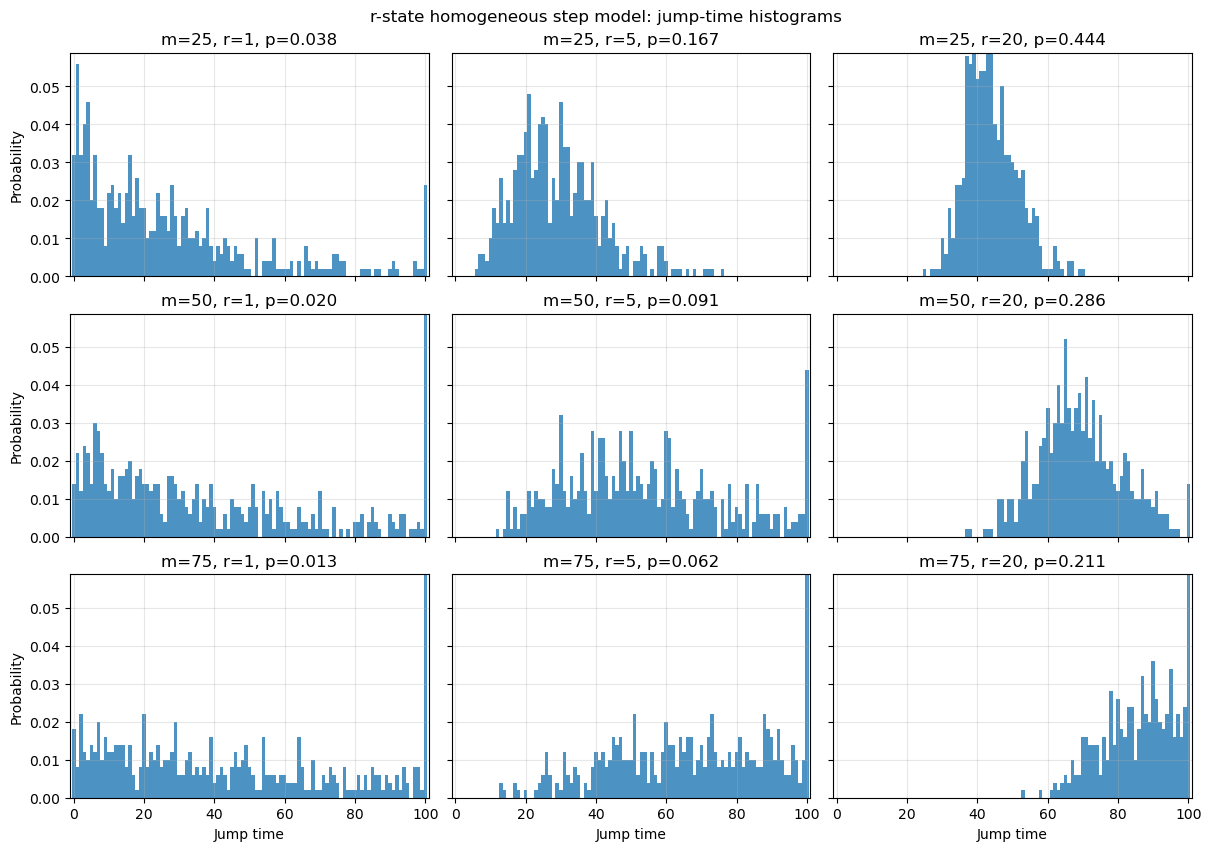

In [27]:
# Sweep over separate m and r arrays
T = 100
m_values = [T//4, T//2, 3*T//4]
r_values = [1, 5, 20]

n_trials = 500
n_plot_trials = 8
x0 = 0.3
Rh = 50

# Store results so the same simulations are used for both figures
results = {}

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        Ps, pi, p = build_step_hmm_rstates(m=m, r=r)

        states, _, rates, _, jumps = simulate_discrete_step(
            Ps, pi,
            T=T,
            x0=x0,
            Rh=Rh,
            n_trials=n_trials
        )

        results[(m, r)] = {
            "p": p,
            "jumps": jumps,
            "rates": rates
        }

fig, axes = plt.subplots(
    len(m_values),
    len(r_values),
    figsize=(4 * len(r_values), 2.8 * len(m_values)),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        ax = axes[i, j]
        rates = results[(m, r)]["rates"]
        p = results[(m, r)]["p"]

        for trial in range(n_plot_trials):
            ax.plot(rates[trial], alpha=0.8)

        ax.set_title(f"m={m}, r={r}, p={p:.3f}")
        ax.set_ylim(0, 1.1 * Rh)
        ax.grid(alpha=0.3)

        if i == len(m_values) - 1:
            ax.set_xlabel("Time step")
        if j == 0:
            ax.set_ylabel("Firing rate")

fig.suptitle("r-state homogeneous step model: firing-rate trajectories")
plt.show()

fig, axes = plt.subplots(
    len(m_values),
    len(r_values),
    figsize=(4 * len(r_values), 2.8 * len(m_values)),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        ax = axes[i, j]
        jumps = results[(m, r)]["jumps"]
        p = results[(m, r)]["p"]

        ax.hist(
            jumps,
            bins=np.arange(T + 2) - 0.5,
            density=True,
            alpha=0.8
        )

        ax.set_title(f"m={m}, r={r}, p={p:.3f}")
        ax.set_xlim(-1, T + 1)
        ax.set_ylim(0, ax.get_ylim()[1])  # ensure y-axis starts at 0
        ax.grid(alpha=0.3)

        if i == len(m_values) - 1:
            ax.set_xlabel("Jump time")
        if j == 0:
            ax.set_ylabel("Probability")

fig.suptitle("r-state homogeneous step model: jump-time histograms")
plt.show()

Notice that the rstate model is not perfectly representative, as the mode jump time does not concentrate exactly about the mean as desired, instead shifted by r, likely virtue of the steps through the $r+1$ states required until jump, and the time-homogenous probability of incrementing the state at each time step. 

In [8]:
def build_step_hmm_time_inhomogeneous(T = 100, m=50, r=20):
    """
    Build an exact time-inhomogeneous two-state HMM for the step model.

    State 0: pre-jump / low-rate state
    State 1: post-jump / high-rate state

    Returns
    -------
    Ps : ndarray, shape (T - 1, 2, 2)
        Time-varying transition matrices. Ps[t-1] maps state at t-1 to state at t.
    pi : ndarray, shape (2,)
        Initial state distribution at t=0.
    p : float
        Negative Binomial success probability.
    q : ndarray, shape (T,)
        Hazard probabilities q[t] = P(tau=t | tau>=t).
    """
    p = r / (m + r)

    # Initial probability of already being high at t=0
    pmf0 = nbinom.pmf(0, r, p)
    pi = np.array([1 - pmf0, pmf0])

    # Time-dependent transition matrices
    Ps = np.zeros((T - 1, 2, 2))  # consider third dimension is time
    q = np.zeros(T)

    for t in range(1, T):
        # q_t = P(tau=t | tau>=t)
        pmf_t = nbinom.pmf(t, r, p)
        surv_t = nbinom.sf(t - 1, r, p)  # P(tau >= t)

        q[t] = pmf_t / surv_t if surv_t > 0 else 1.0

        Ps[t - 1] = np.array([
            [1 - q[t], q[t]],
            [0,        1]
        ])

    return Ps, pi, p, q

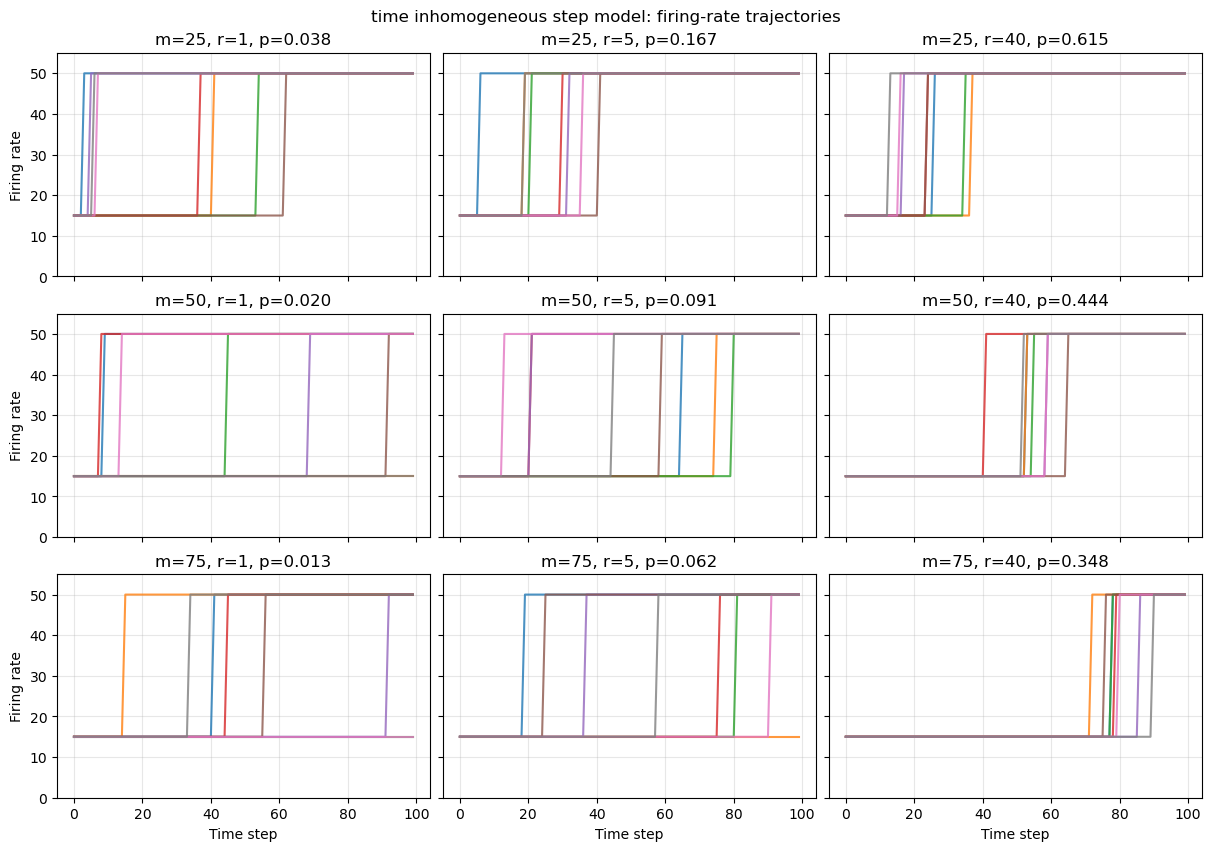

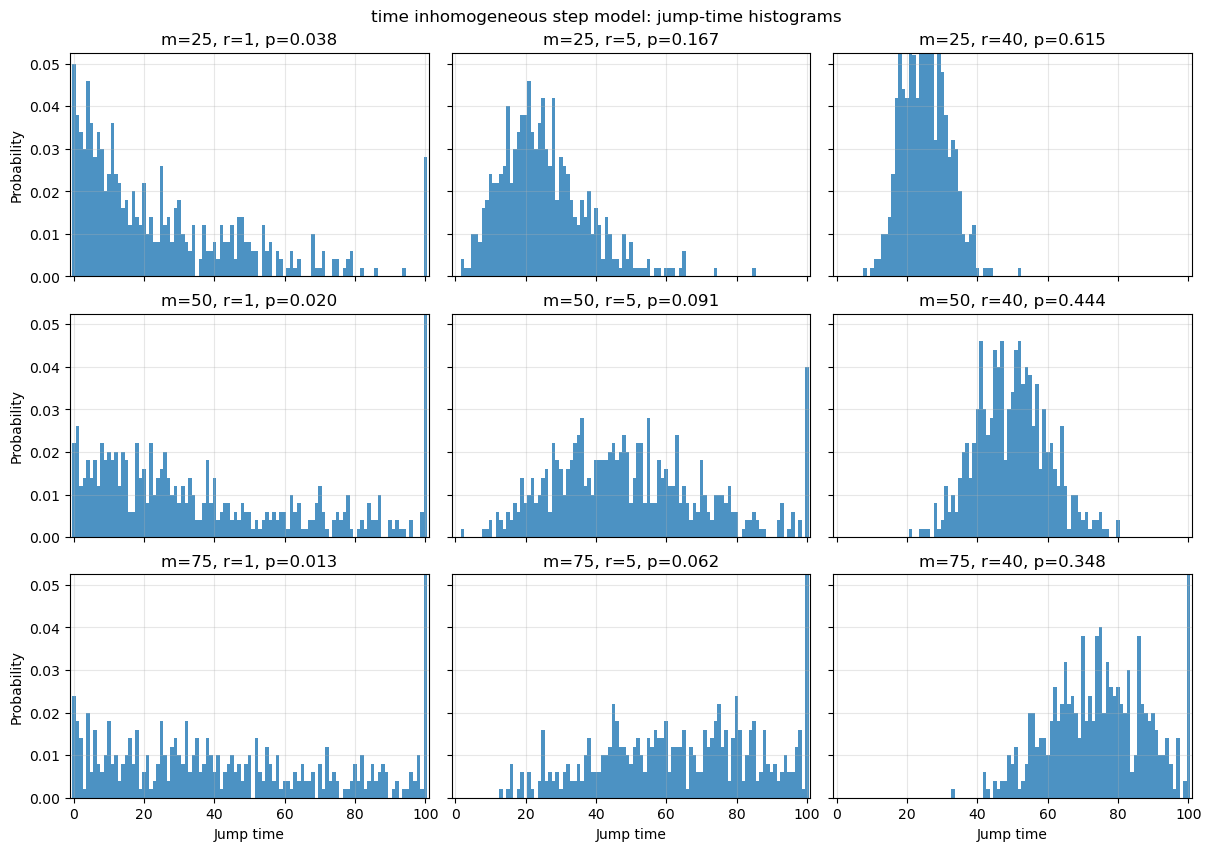

In [53]:
# Sweep over separate m and r arrays
T = 100
m_values = [T//4, T//2, 3*T//4]
r_values = [1, 5, 40]

n_trials = 500
n_plot_trials = 8
x0 = 0.3
Rh = 50

# Store results so the same simulations are used for both figures
results = {}

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        Ps, pi, p, q = build_step_hmm_time_inhomogeneous(T=T, m=m, r=r)

# simulate_discrete_step(Ps, pi, T = 100, x0 = 0.3, Rh = 50, K = 2, n_trials=5)
# simulate_time_inhomogeneous_step(Ps, pi, T_steps=100, x0=0.3, Rh=50, n_trials=100)
        states, _, rates, _, jumps= simulate_discrete_step(
            Ps, pi,
            T=T,
            x0=x0,
            Rh=Rh,
            n_trials=n_trials
        )

        results[(m, r)] = {
            "p": p,
            "jumps": jumps,
            "rates": rates
        }

fig, axes = plt.subplots(
    len(m_values),
    len(r_values),
    figsize=(4 * len(r_values), 2.8 * len(m_values)),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        ax = axes[i, j]
        rates = results[(m, r)]["rates"]
        p = results[(m, r)]["p"]

        for trial in range(n_plot_trials):
            ax.plot(rates[trial], alpha=0.8)

        ax.set_title(f"m={m}, r={r}, p={p:.3f}")
        ax.set_ylim(0, 1.1 * Rh)
        ax.grid(alpha=0.3)

        if i == len(m_values) - 1:
            ax.set_xlabel("Time step")
        if j == 0:
            ax.set_ylabel("Firing rate")

fig.suptitle("time inhomogeneous step model: firing-rate trajectories")
plt.show()

fig, axes = plt.subplots(
    len(m_values),
    len(r_values),
    figsize=(4 * len(r_values), 2.8 * len(m_values)),
    constrained_layout=True,
    sharex=True,
    sharey=True
)

for i, m in enumerate(m_values):
    for j, r in enumerate(r_values):
        ax = axes[i, j]
        jumps = results[(m, r)]["jumps"]
        p = results[(m, r)]["p"]

        ax.hist(
            jumps,
            bins=np.arange(T + 2) - 0.5,
            density=True,
            alpha=0.8
        )

        ax.set_title(f"m={m}, r={r}, p={p:.3f}")
        ax.set_xlim(-1, T + 1)
        ax.set_ylim(0, ax.get_ylim()[1])  # ensure y-axis starts at 0
        ax.grid(alpha=0.3)

        if i == len(m_values) - 1:
            ax.set_xlabel("Jump time")
        if j == 0:
            ax.set_ylabel("Probability")

fig.suptitle("time inhomogeneous step model: jump-time histograms")
plt.show()

Exact time-inhomogeneous two-state formulation

The original step model can be represented exactly using a two-state Markov chain if the transition probabilities are allowed to depend on time. The two states are the pre-jump state and post-jump state,
$
s_t \in \{0,1\},
$
where state \(0\) emits the low firing rate $x_0R_h$, and state $1$ emits the high firing rate $R_h$. The high state is absorbing.

In the original model, the jump time is sampled as
$$
\tau \sim \mathrm{NB}(r,p), \qquad p=\frac{r}{m+r}.
$$
To reproduce this exactly, the low-to-high transition probability at time $t$ is chosen as the Negative Binomial hazard,
$$
q_t = P(\tau=t \mid \tau \geq t)
    = \frac{P(\tau=t)}{P(\tau \geq t)}.
$$
Hence the time-dependent transition matrix from \(t-1\) to \(t\) is
$$
T_t =
\begin{pmatrix}
1-q_t & q_t \\
0 & 1
\end{pmatrix}.
$$
The initial distribution also accounts for jumps at \(t=0\):
$$
\pi = \left(1-P(\tau=0),\; P(\tau=0)\right)
    = \left(1-p^r,\; p^r\right).
$$

This construction is exact because the first transition into the absorbing high state occurs with probability $P(\tau=t)$, matching the original Negative Binomial jump-time distribution. However, because $q_t$ varies with time, this is a time-inhomogeneous HMM, whereas the main task asks for a time-homogeneous formulation.

### Task 2.3:  Inference of hidden states

Henceforth, for the rest of the activities this week (as well as most of the activities of the next two weeks), we will be solely working with the discrete-state HMM versions of the two models that you have implemented (instead of using the `models.py` simulators). We will also limit the values of the parameter $r$ to positive integers.

The `hmm_expected_states` function (see its doc/help) in the `inference.py` (run the next code cell to import this on Colab [**§**]) module implements the forward-backward algorithm (FBA) to calculate the posterior probabilities $P(s_t | n_{1:T})$, as well as the log-likelihood $\ln P(n_{1:T})$ [**§§**]. One of the inputs to `hmm_expected_states` is the array, `ll`, of the logs of the conditional observation probabilities $ll[t, s] = \log P(n_t|s_t = s)$ [**§§§**]. Use the function `inference.poisson_logpdf` from the provided new module `inference.py`, to construct this array based on the observed spike counts of one or several trials (see the help of this function).



Use this function to obtain the posterior probabilities, $P(s_t | n_{1:T})$, for your finite-state HMM implementations of both models [**§§§§**].

- Write code to calcualte the posterior expectation of $x_t$ (i.e. $\mathbb{E}[x_t | n_{1:T}]$), for the ramp model, based on the posterior probabilities $P(s_t | n_{1:T})$. Generate several trial spike trains using the discrete-state HMM ramp model (with the corresponding $x_t$ trajectories retained), and for each trial infer and plot $\mathbb{E}[x_t | n_{1:T}]$, together with the ground-truth simulated $x_t$. Repeat this in different regions of model parameter space (including low and high values of $x_0$ and $R_h$). In what parameter regimes is the inference more accurate, and vice versa? Provide intuitive/qualitative explanations for your observations. 

- Repeat the above for the step model, with the following modifications. The aspect of the step model's hidden states that we really care about is whether or not the ''neuron" has jumped to the upper rate level. Calculate the probability of being in the upper rate level based on the posterior state probabilities $P(s_t | n_{1:T})$, and again make plots of it for various simulated spike-train trials. Visualise the true jump time on these plots. You can take the time point when the posterior probability of being in the upper rate level exceeds 0.5 as the estimated/inferred jump time, and mark that on the plots as well.<br>
For your report, try to combine different trials in one plot or figure, in a compact but nice way.<br> Based on these plots, comment (include both accounts of your observations and your qualitative explanations for them) on the accuracy  of the inference in different regions of the model parameter space. 

- The `hmm_expected_states` function has an optional boolean input `filter` which is false by default. When true, the function calculates $P(s_t | n_{1:t})$ instead of $P(s_t | n_{1:T})$: i.e. the posterior conditioned only on observations up to and including the "current" time-step $t$. This corresponds to the so-called filtering problem (as in the Kalman filter; the default case, `filter = False`, corresponds to "smoothing"). Filtering is appropriate for applications where inference has to be performed online, in which case, to infer $x_t$ we do not have the luxury of having access to future observations -- without a time-machine, that is! In our case (as engineers studying the computational mechanisms in area LIP), we do of course have access to the entire spike-train; hence the default option. Nevertheless, carry out a theoretical study of the differences in inference accuracy, for both models, using smoothing vs. filtering. What qualitative differences do you observe between the inference accuracy using filtering vs. smoothing? 

In all of the above sub-tasks,  quantiatify the latent-state inference accuracy by evaluating the average error (both over trials and over time, if the latter makes sense) of the posterior estimates of the $x_t$ trajectories (for the ramp model) or the jump times (for the step model). You can then make heatmap or contour plots of these errors as a function of two parameters -- and different plots for different choices of parameter pairs. (The `tricontourf` function of `matplotlib` is very useful for this purpose.)

----

**§:** The module `inference.py` makes use of the [Numba package](http://numba.pydata.org/) to speed up computations by so-called just-in-time (JIT) compilation.  Numba can be imported in Colab, but to use it locally, you will need to install it, following these [instructions](https://numba.readthedocs.io/en/stable/user/installing.html).
Also note that JIT makes a function run slowly the first time you use it. So the first time you run a JITed function (e.g. `hmm_expected_states`) it's better to run it on a "light" test case (e.g. a single spike train, rather than several spike trains, or on a short one), and only then run it for the true use case.  


**§§:** This (log) probability depends implicitly on model parameters, hence the name (log) likelihood; it is called `normalizer` in the code for reasons having to do with the fact that it normalizes the message products involved in the FBA.

**§§§:** Note that at inference time, the $n_t$ are known and fixed, but the MC states are unknown; thus, as part of the inference procedure, we need to evaluate the observation (log-)probabilities for *all* possible states, $s$, at *every* times $t$. For more details see my [notes on the FBA](https://github.com/ghennequin/gg3/blob/main/fwdbwd.ipynb).


**§§§§:** Note that the observed spike trains used here (and later in Weeks 3 & 4) should be generated using the discrete-state HMM version of the two models. For this, first generate the latent variables as in tasks 2.1 and 2.2, and calculate the firing rates, $r_t$, based on them. Then, given the rates, sample the spike counts, $n_t$, from the corresponding Poisson distribution (you can look up how this was done in `models.py`).


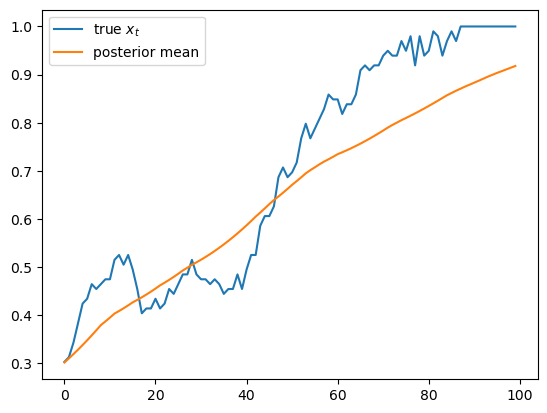

In [19]:
# 1. Simulate data
T = 100
dt = 1/T
Rh = 50

Ps, pi = build_ramp_hmm(K=100, beta=0.85, sigma=0.25, x0=0.3, T=T)
states, xs, rates, spikes = simulate_discrete_ramp(Ps = Ps, pi=pi, T=T)

# 2. Define state-to-rate mapping
K = len(pi)
x_by_state = np.arange(K) / (K - 1)
rates_by_state = Rh * x_by_state
lambdas_by_state = rates_by_state * dt

# 3. Build emission log-likelihoods
ll = inference.poisson_logpdf(spikes[0].astype(int), lambdas_by_state.copy())

# 4. Run forward-backward
posterior, loglik = inference.hmm_expected_states(pi, Ps, ll)

# 5. Convert posterior state probabilities to posterior mean x_t
x_hat = posterior @ x_by_state

# 6. Compare against true latent trajectory
plt.plot(xs[0], label="true $x_t$")
plt.plot(x_hat, label="posterior mean")
plt.legend()

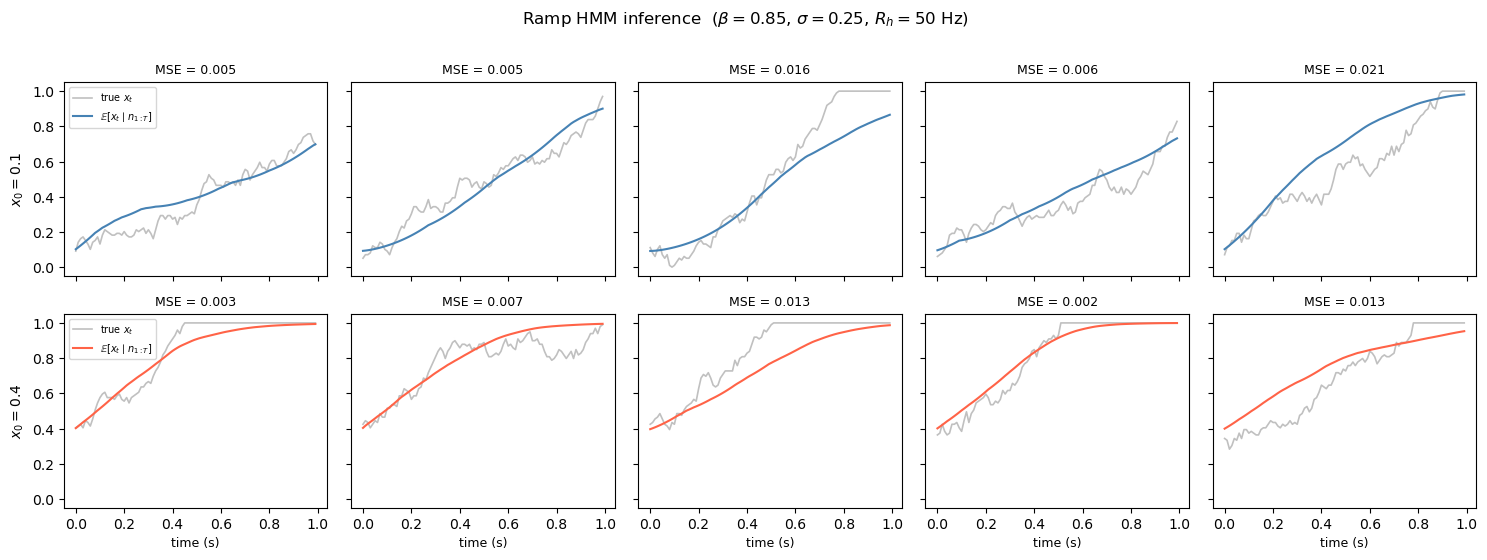

In [43]:
# =============================================================
# Task 2.3 — Block 1: Ramp model, multi-trial inference demo
# =============================================================

# === PARAMS (change these) ===
T       = 100
K       = 100
Rh      = 50        # peak firing rate (Hz)
DT      = 1 / T
BETA    = 0.85
SIGMA   = 0.25
N_PLOT  = 5         # trials per row

X0_LOW  = 0.1      # low start: full dynamic range → clearer signal
X0_HIGH = 0.4      # high start: compressed range → weaker signal
# ==============================

np.random.seed(42)
time       = np.arange(T) / T
x_by_state = np.arange(K) / (K - 1)
lambdas    = Rh * x_by_state * DT   # expected spike count per bin, per state

fig, axes = plt.subplots(2, N_PLOT, figsize=(3 * N_PLOT, 5.5), sharey=True, sharex=True)
colours   = ['steelblue', 'tomato']

for row_idx, x0 in enumerate([X0_LOW, X0_HIGH]):
    Ps, pi = build_ramp_hmm(K=K, beta=BETA, sigma=SIGMA, T=T, x0=x0)
    states, xs, rates, spikes = simulate_discrete_ramp(T=T, pi=pi, Ps=Ps, n_trials=N_PLOT)

    for col in range(N_PLOT):
        ax  = axes[row_idx, col]
        ll  = inference.poisson_logpdf(spikes[col].astype(int), lambdas.copy())
        posterior, _ = inference.hmm_expected_states(pi, Ps, ll)
        x_hat = posterior @ x_by_state
        mse   = np.mean((xs[col] - x_hat) ** 2)

        ax.plot(time, xs[col], color='silver',         lw=1.2, label='true $x_t$')
        ax.plot(time, x_hat,   color=colours[row_idx], lw=1.5, label=r'$\mathbb{E}[x_t \mid n_{1:T}]$')
        ax.set_title(f'MSE = {mse:.3f}', fontsize=9)
        ax.set_ylim(-0.05, 1.05)

        if col == 0:
            ax.set_ylabel(f'$x_0 = {x0}$', fontsize=10)
            ax.legend(fontsize=7, loc='upper left')
        if row_idx == 1:
            ax.set_xlabel('time (s)', fontsize=9)

fig.suptitle(
    fr'Ramp HMM inference  ($\beta={BETA}$, $\sigma={SIGMA}$, $R_h={Rh}$ Hz)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

#### Block 1 analysis: Ramp inference accuracy — qualitative observations

**High $\beta$, low $\sigma$ → accurate inference.** A fast drift with little diffusion noise produces a clear, monotone $x_t$ trajectory; spike counts rise predictably, giving the forward-backward algorithm a strong signal to track $x_t$ closely.

**High $\sigma$ → wider posterior, higher MSE.** Large diffusion noise makes individual-trial trajectories meander unpredictably between trials. The posterior mean averages over all plausible paths consistent with the spikes, yielding an estimate that smooths over true fluctuations.

**The effect of $x_0$ on ramp inference is the opposite of what one might expect.** With high $x_0$ (bottom row), the ramp starts near the absorbing boundary and quickly saturates at $x_t = 1$; the neuron fires at near-$R_h$ rates for most of the trial, and the posterior confidently sits near 1 — yielding lower MSE. With low $x_0$ (top row), the trajectory is actively changing throughout the trial, requiring the smoother to continuously track a moving target, which is harder and accumulates more error over time.

**$R_h$ acts through a different channel.** Unlike $x_0$, lowering $R_h$ reduces the average spike count per bin across all states, weakening the signal at every time step regardless of trajectory dynamics. Varying $x_0$ changes the temporal pattern of uncertainty (when the trajectory is hardest to track), while varying $R_h$ changes the overall signal strength uniformly.

In [38]:
# =============================================================
# Task 2.3 — Block 2: Ramp model, accuracy heatmap
# =============================================================

# === PARAMS (change these) ===
T             = 100
K             = 100
Rh            = 50
DT            = 1 / T
N_TRIALS_HEAT = 30 

X0_LOW        = 0.05
X0_HIGH       = 0.4

BETA_VALS     = np.linspace(0, 4, 6)
LOG_SIG_VALS  = np.linspace(np.log(0.04), np.log(4), 6)
# ==============================

np.random.seed(0)


def compute_ramp_mse_grid(beta_vals, log_sig_vals, x0, K, Rh, T, n_trials):
    """
    Compute mean MSE of ramp posterior-mean inference over a (beta, log-sigma) grid.

    Returns
    -------
    mse_grid : ndarray, shape (len(beta_vals), len(log_sig_vals))
    """
    dt_      = 1 / T
    x_st     = np.arange(K) / (K - 1)
    lams     = Rh * x_st * dt_
    mse_grid = np.zeros((len(beta_vals), len(log_sig_vals)))

    for i, beta in enumerate(beta_vals):
        for j, log_sig in enumerate(log_sig_vals):
            sigma = np.exp(log_sig)
            Ps, pi = build_ramp_hmm(K=K, beta=beta, sigma=sigma, T=T, x0=x0)
            _, xs, _, spikes = simulate_discrete_ramp(T=T, pi=pi, Ps=Ps, n_trials=n_trials)
            trial_mses = []
            for tr in range(n_trials):
                ll = inference.poisson_logpdf(spikes[tr].astype(int), lams.copy())
                post, _ = inference.hmm_expected_states(pi, Ps, ll)
                x_hat   = post @ x_st
                trial_mses.append(np.mean((xs[tr] - x_hat) ** 2))
            mse_grid[i, j] = np.mean(trial_mses)
    return mse_grid

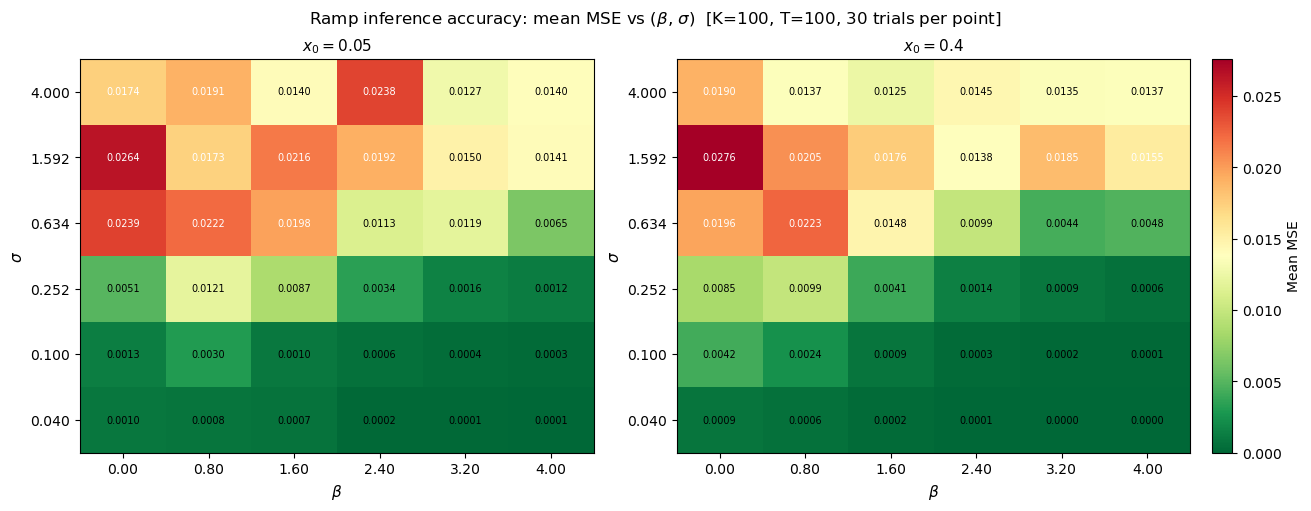

In [39]:
grid_low  = compute_ramp_mse_grid(BETA_VALS, LOG_SIG_VALS, X0_LOW,  K, Rh, T, N_TRIALS_HEAT)
grid_high = compute_ramp_mse_grid(BETA_VALS, LOG_SIG_VALS, X0_HIGH, K, Rh, T, N_TRIALS_HEAT)


sig_labels  = [f'{np.exp(v):.3f}' for v in LOG_SIG_VALS]
beta_labels = [f'{b:.2f}' for b in BETA_VALS]

vmax = max(grid_low.max(), grid_high.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, grid, x0 in zip(axes, [grid_low, grid_high], [X0_LOW, X0_HIGH]):
    im = ax.imshow(grid.T, origin='lower', aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=vmax)

    # annotate each cell with its numeric value
    thresh = 0.55 * vmax
    for i in range(grid.shape[1]):
        for j in range(grid.shape[0]):
            col = 'white' if grid[j, i] > thresh else 'black'
            ax.text(j, i, f'{grid[j, i]:.4f}', ha='center', va='center',
                    fontsize=7, color=col)

    ax.set_xticks(range(len(BETA_VALS)));     ax.set_xticklabels(beta_labels)
    ax.set_yticks(range(len(LOG_SIG_VALS)));  ax.set_yticklabels(sig_labels)
    ax.set_xlabel(r'$\beta$',  fontsize=11)
    ax.set_ylabel(r'$\sigma$', fontsize=11)
    ax.set_title(f'$x_0 = {x0}$', fontsize=11)

cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.02)
cbar.set_label('Mean MSE', fontsize=10)

fig.suptitle(
    f'Ramp inference accuracy: mean MSE vs ($\\beta$, $\\sigma$)  '
    f'[K={K}, T={T}, {N_TRIALS_HEAT} trials per point]',
    fontsize=12
)
plt.show()

#### Block 2 analysis: Ramp inference accuracy heatmap — observations

**$\sigma$ is the dominant driver of MSE, but with a non-monotone relationship.** MSE rises as $\sigma$ increases from the left, peaking around $\sigma \approx 1.6$ in both panels. Crucially, the rightmost column ($\sigma = 4.0$) is *better* than the $\sigma = 1.6$ column. At very high diffusion, the trajectory quickly diffuses to the absorbing state at $x_t = 1$ and stays there; the posterior then trivially concentrates near 1 for most of the trial, artificially lowering MSE. The hardest regime is therefore intermediate $\sigma$ where the trajectory is maximally variable without saturating quickly.

**Low $\beta$ + mid $\sigma$ is the worst combination.** The darkest cell in both panels is in the bottom row ($\beta \approx 0$) at $\sigma \approx 1.6$. A near-zero drift means the trajectory barely rises on average, yet mid-range diffusion creates large trial-to-trial variability that the smoother cannot track without a drift signal to anchor it.

**The two panels are broadly comparable, with a shifted worst-case.** The max MSE is similar (~0.027–0.028) in both panels. For $x_0 = 0.4$ the peak shifts slightly upward in $\beta$ (to $\beta \approx 0.8$, $\sigma \approx 1.6$): when the ramp starts high, a moderate drift causes the trajectory to hover in the uncertain mid-range longest before saturating, whereas a very slow drift ($\beta \approx 0$) becomes easier because the initial high rate already narrows the posterior. The low-$\sigma$, high-$\beta$ corner (top-left) is best in both panels, confirming that fast, clean ramps are the easiest to infer regardless of $x_0$.

In [48]:
# =============================================================
# Task 2.3 — Block 3: Step model, generalised inference demo
# =============================================================

# === PARAMS (change these) ===
T          = 100
Rh         = 50
DT         = 1 / T
M_DEMO     = 50
R_DEMO     = 50
N_PLOT     = 5
MODEL_TYPE = 'rstate'  # options: 'time_inhomogeneous' | '2state' | 'rstate'

X0_LOW     = 0.1   # large rate contrast -> easier detection
X0_HIGH    = 0.4   # small rate contrast -> harder detection
# ==============================


def build_step_hmm_for_inference(model_type='time_inhomogeneous', T=100, m=50, r=10, x0=0.2, Rh=50):
    """
    Dispatcher: builds the chosen step-model HMM variant and returns the
    matching per-state Poisson emission rates (scaled by dt).

    Parameters
    ----------
    model_type : str
        'time_inhomogeneous' (default, exact 2-state),
        '2state' (time-homogeneous 2-state approximation), or
        'rstate' (time-homogeneous (r+1)-state approximation).

    Returns
    -------
    Ps      : ndarray, shape (K, K) or (T-1, K, K)
    pi      : ndarray, shape (K,)
    lambdas : ndarray, shape (K,)   — Poisson rate * dt per state
    """
    dt = 1 / T
    if model_type == 'time_inhomogeneous':
        Ps, pi, p, q = build_step_hmm_time_inhomogeneous(T=T, m=m, r=r)
        lambdas = np.array([x0 * Rh * dt, Rh * dt])
    elif model_type == '2state':
        Ps, pi, p = build_step_hmm_2states(m=m, r=r)
        lambdas = np.array([x0 * Rh * dt, Rh * dt])
    elif model_type == 'rstate':
        Ps, pi, p = build_step_hmm_rstates(m=m, r=r)
        lambdas = np.array([x0 * Rh * dt] * r + [Rh * dt])
    else:
        raise ValueError(f"Unknown model_type {model_type!r}. "
                         "Choose 'time_inhomogeneous', '2state', or 'rstate'.")
    return Ps, pi, lambdas




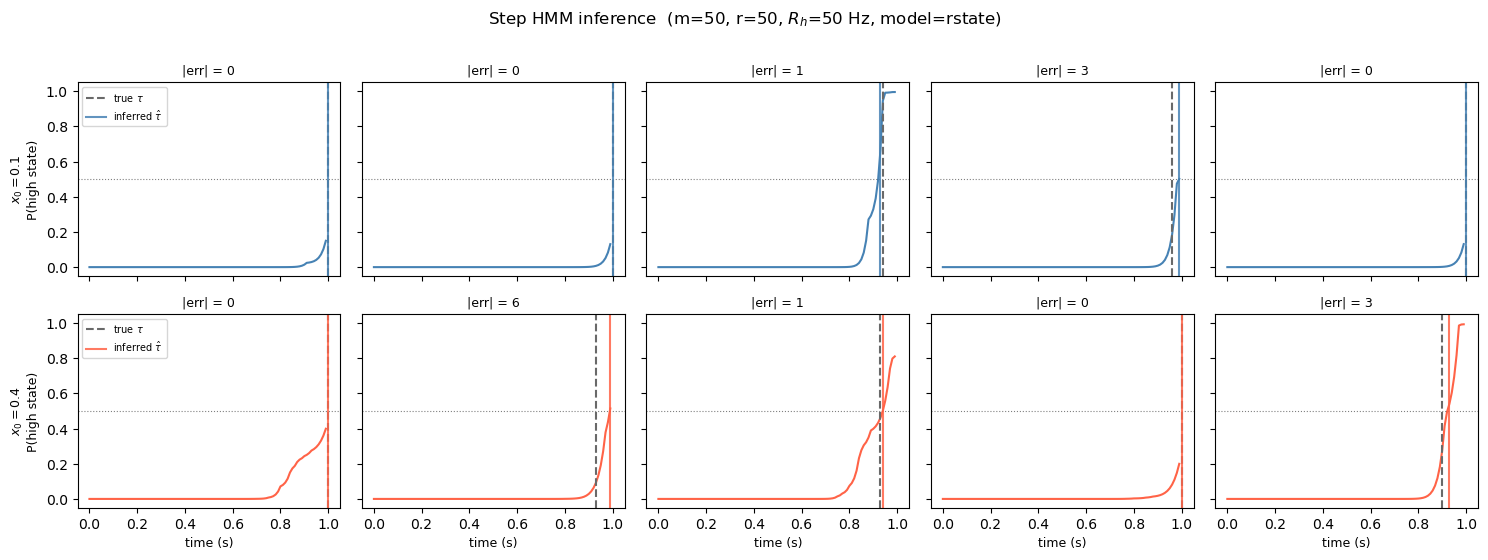

In [49]:
np.random.seed(7)
time    = np.arange(T) / T
colours = ['steelblue', 'tomato']

fig, axes = plt.subplots(2, N_PLOT, figsize=(3 * N_PLOT, 5.5), sharey=True, sharex=True)

for row_idx, x0 in enumerate([X0_LOW, X0_HIGH]):
    Ps, pi, lambdas = build_step_hmm_for_inference(
        model_type=MODEL_TYPE, T=T, m=M_DEMO, r=R_DEMO, x0=x0, Rh=Rh
    )
    _, _, _, spikes, jumps = simulate_discrete_step(Ps=Ps, pi=pi, T=T, x0=x0, Rh=Rh, n_trials=N_PLOT)

    for col in range(N_PLOT):
        ax = axes[row_idx, col]
        ll = inference.poisson_logpdf(spikes[col].astype(int), lambdas.copy())
        posterior, _ = inference.hmm_expected_states(pi, Ps, ll)
        p_high = posterior[:, -1]     # P(post-jump / high state) — always last state index

        above = np.where(p_high > 0.5)[0]
        inferred_jump = above[0] if len(above) > 0 else T

        ax.plot(time, p_high, color=colours[row_idx], lw=1.5)
        ax.axhline(0.5, color='k', lw=0.8, ls=':', alpha=0.5)
        ax.axvline(jumps[col] / T, color='dimgrey',         lw=1.5, ls='--', label='true $\\tau$')
        ax.axvline(inferred_jump / T, color=colours[row_idx], lw=1.5, ls='-',  label=r'inferred $\hat{\tau}$',
                   alpha=0.85)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'|err| = {abs(inferred_jump - jumps[col])}', fontsize=9)

        if col == 0:
            ax.set_ylabel(f'$x_0 = {x0}$\nP(high state)', fontsize=9)
            ax.legend(fontsize=7, loc='upper left')
        if row_idx == 1:
            ax.set_xlabel('time (s)', fontsize=9)

fig.suptitle(
    f'Step HMM inference  (m={M_DEMO}, r={R_DEMO}, $R_h$={Rh} Hz, '
    f'model={MODEL_TYPE})',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

#### Block 3 analysis: Step inference accuracy — qualitative observations

**Low $x_0$ (top row) → sharp P(high) transition, accurate jump detection.** When $x_0$ is small, the rate contrast between the pre-jump state ($x_0 R_h \Delta t$ spikes/bin) and the post-jump state ($R_h \Delta t$ spikes/bin) is large. The forward-backward algorithm detects this change quickly and P(high state) rises steeply near the true jump, yielding small absolute errors.

**High $x_0$ (bottom row) → gradual P(high) rise, late or unreliable detection.** With $x_0 = 0.4$, both states produce similar spike counts per bin. The algorithm struggles to distinguish them and P(high) rises slowly and noisily; the inferred jump either lags the true one or never crosses 0.5 when jumps occur late in the trial. This is mechanistically the same as reducing $R_h$: both shrink the rate contrast $R_h(1 - x_0)\Delta t$.

**Large $r$ (concentrated NB distribution) → easier localisation.** When $r$ is large the jump time is tightly concentrated around $m$; the algorithm can focus its evidence around the expected window and confirm the jump quickly after it occurs.

**Small $r$ (dispersed jumps) → hedged, slowly rising posterior.** With $r = 1$ the jump time is geometrically distributed across the whole trial. The algorithm spreads probability across all possible jump times, producing a gradually rising P(high) that often mis-locates the jump.

**Late jumps → harder inference.** When the true jump occurs near $t = T$ there are few post-jump time steps to confirm the state change, so the posterior remains uncertain regardless of $x_0$ or $r$.

Computing error grids (may take ~60 s)...
Done.


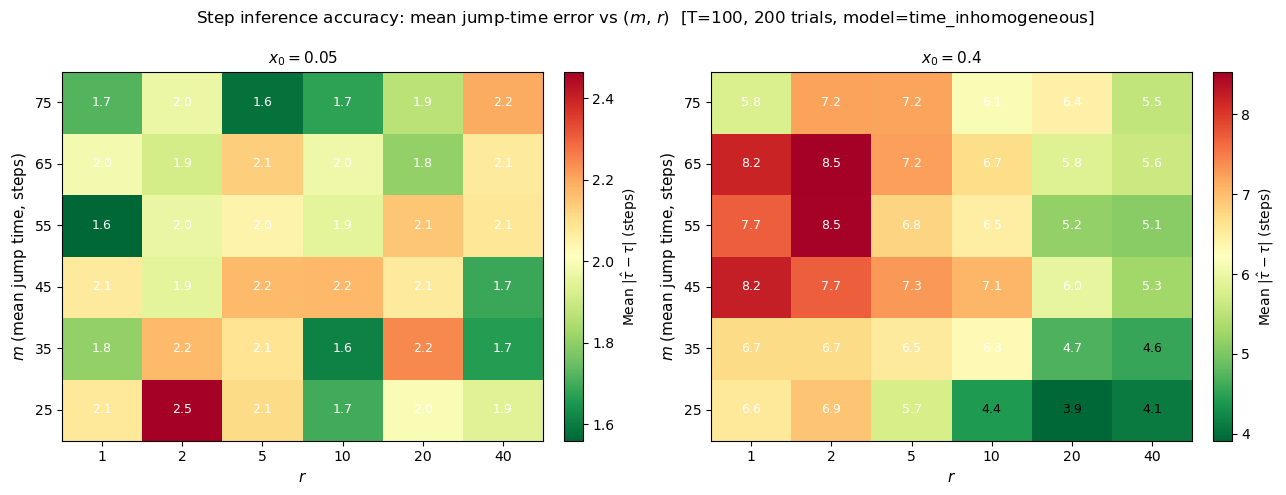

In [52]:
# =============================================================
# Task 2.3 — Block 4: Step model, accuracy heatmap
# =============================================================

# === PARAMS (change these) ===
T             = 100
Rh            = 50
DT            = 1 / T
N_TRIALS_HEAT = 200
MODEL_TYPE    = 'time_inhomogeneous'   # '2state' | 'rstate' | 'time_inhomogeneous'

X0_LOW        = 0.05
X0_HIGH       = 0.4

M_VALS = np.linspace(T//4, 3*T//4, 6, dtype=int)
R_VALS = np.array([1, 2, 5, 10, 20, 40])
# ==============================

np.random.seed(1)


def compute_step_error_grid(m_vals, r_vals, model_type, x0, Rh, T, n_trials):
    """
    Compute mean absolute jump-time inference error over an (m, r) grid.

    Returns
    -------
    err_grid : ndarray, shape (len(r_vals), len(m_vals))
        Trials where P(high) never exceeds 0.5 are assigned inferred_jump = T.
    """
    err_grid = np.zeros((len(r_vals), len(m_vals)))
    for i, r in enumerate(r_vals):
        for j, m in enumerate(m_vals):
            Ps, pi, lambdas = build_step_hmm_for_inference(
                model_type=model_type, T=T, m=int(m), r=int(r), x0=x0, Rh=Rh
            )
            _, _, _, spikes, jumps = simulate_discrete_step(
                Ps=Ps, pi=pi, T=T, x0=x0, Rh=Rh, n_trials=n_trials
            )
            trial_errs = []
            for tr in range(n_trials):
                ll   = inference.poisson_logpdf(spikes[tr].astype(int), lambdas.copy())
                post, _ = inference.hmm_expected_states(pi, Ps, ll)
                above    = np.where(post[:, -1] > 0.5)[0]
                inferred = above[0] if len(above) > 0 else T
                trial_errs.append(abs(inferred - jumps[tr]))
            err_grid[i, j] = np.mean(trial_errs)
    return err_grid


print("Computing error grids (may take ~60 s)...")
grid_low  = compute_step_error_grid(M_VALS, R_VALS, MODEL_TYPE, X0_LOW,  Rh, T, N_TRIALS_HEAT)
grid_high = compute_step_error_grid(M_VALS, R_VALS, MODEL_TYPE, X0_HIGH, Rh, T, N_TRIALS_HEAT)
print("Done.")

m_labels = [str(m) for m in M_VALS]
r_labels = [str(r) for r in R_VALS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, grid, x0 in zip(axes, [grid_low, grid_high], [X0_LOW, X0_HIGH]):
    im   = ax.imshow(grid.T, origin='lower', aspect='auto', cmap='RdYlGn_r')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'Mean $|\hat{\tau} - \tau|$ (steps)', fontsize=10)

    # annotate each cell
    thresh = 0.55 * grid.max()
    for i in range(grid.shape[1]):
        for j in range(grid.shape[0]):
            col = 'white' if grid[j, i] > thresh else 'black'
            ax.text(j, i, f'{grid[j, i]:.1f}', ha='center', va='center',
                    fontsize=9, color=col)

    ax.set_xticks(range(len(R_VALS)));  ax.set_xticklabels(r_labels)
    ax.set_yticks(range(len(M_VALS)));  ax.set_yticklabels(m_labels)
    ax.set_xlabel('$r$', fontsize=11)
    ax.set_ylabel('$m$ (mean jump time, steps)', fontsize=11)
    ax.set_title(f'$x_0 = {x0}$', fontsize=11)

fig.suptitle(
    f'Step inference accuracy: mean jump-time error vs ($m$, $r$)  '
    f'[T={T}, {N_TRIALS_HEAT} trials, model={MODEL_TYPE}]',
    fontsize=12
)
plt.tight_layout()
plt.show()

#### Block 4 analysis: Step inference accuracy heatmap — observations

**$x_0 = 0.1$: near-uniform, low error (~2–3 steps) across the entire grid.** With strong rate contrast, the algorithm detects the jump reliably regardless of $m$ or $r$. The ~2 step floor likely represents the irreducible detection delay: even with perfect data the smoother needs at least one or two post-jump spikes to confidently shift $P(\text{high}) > 0.5$. The narrow range (2.1–3.1) means parameter choice has minimal practical impact when the signal is strong.

**$x_0 = 0.4$: errors are 2–3$\times$ higher (4–8 steps) with clear structure.** The reduced rate contrast $(1 - x_0) R_h \Delta t$ makes both states look similar, forcing the algorithm to accumulate many more post-jump observations before committing. This amplifies every source of difficulty that was invisible at $x_0 = 0.1$.

**Large $r$ at small $m$ gives the best performance for $x_0 = 0.4$.** The top-left corner ($r = 40$, $m = 25$: 4.4 steps) is the most favourable: an early, concentrated jump leaves the majority of the trial as post-jump evidence. However, the benefit of large $r$ is not monotone — $r = 10$ and $r = 5$ can perform comparably to or worse than $r = 1$ at certain $m$ values, suggesting the interaction between jump-time uncertainty and signal strength is non-trivial.

**Small $r$ ($r = 1$, $r = 2$) is consistently poor at $x_0 = 0.4$.** A geometrically-distributed jump time (r=1) spreads uncertainty across the whole trial; $P(\text{high})$ rises slowly and the 0.5 threshold crossing can land far from the true jump, yielding errors of 6–8 steps.

**Late $m$ worsens performance at $x_0 = 0.4$, especially at high $r$.** When the jump is expected late there are few post-jump time steps to confirm it. Combined with weak signal, the algorithm often fails to cross 0.5 before $t = T$, pushing errors to the penalty value. This is most visible at $r = 10$, $m = 65$ (8.3 steps), the single worst cell in the grid.

In [56]:
# =============================================================
# Task 2.3 — Block 5: Filtering vs Smoothing
#   Figure A — visual comparison on example trials
#   Figure B — time-resolved error (averaged over trials)
#   Figure C — filter excess-error heatmaps vs parameter pairs
# =============================================================

# === PARAMS (change these) ===
T             = 100
K             = 100
Rh            = 50
DT            = 1 / T
N_TRIALS_FS   = 100      # trials for Figure B (time-resolved)
N_EXCESS      = 50       # trials per grid point for Figure C (faster)
N_VIS         = 2        # example trials for Figure A

X0_LOW        = 0.05
X0_HIGH       = 0.4

BETA_FS       = 2 
SIGMA_FS      = 0.6
M_FS          = 50
R_FS          = 10
MODEL_TYPE_FS = 'time_inhomogeneous'

# Smaller grids for Figure C
BETA_EX     = np.linspace(0, 4, 6)
LOG_SIG_EX  = np.linspace(np.log(0.04), np.log(4), 6)
M_EX        = np.linspace(T//4, 3*T//4, 6, dtype=int)
R_EX        = np.array([1, 2, 5, 10, 20, 40])
# ==============================

time       = np.arange(T) / T
x_by_state = np.arange(K) / (K - 1)



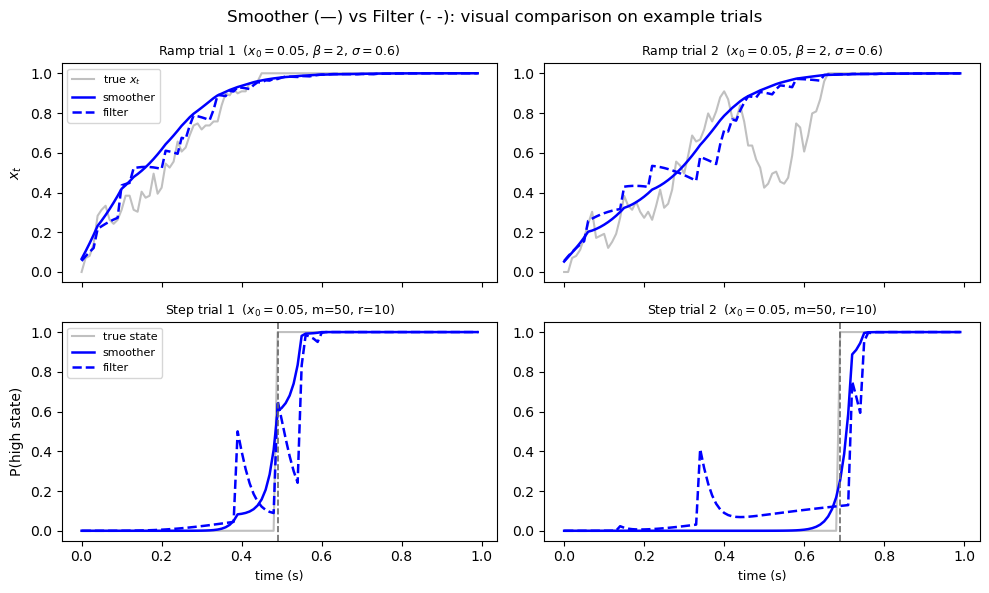

In [57]:
# ── Figure A: Visual comparison ───────────────────────────────────────────────
np.random.seed(7)

fig_a, axes_a = plt.subplots(2, N_VIS, figsize=(5 * N_VIS, 6), sharex=True)

# Top row: ramp model
Ps_r, pi_r = build_ramp_hmm(K=K, beta=BETA_FS, sigma=SIGMA_FS, T=T, x0=X0_LOW)
lams_r     = Rh * x_by_state * DT
_, xs_r, _, spikes_r = simulate_discrete_ramp(T=T, pi=pi_r, Ps=Ps_r, n_trials=N_VIS)

for col in range(N_VIS):
    ax  = axes_a[0, col]
    ll  = inference.poisson_logpdf(spikes_r[col].astype(int), lams_r.copy())
    ps, _ = inference.hmm_expected_states(pi_r, Ps_r, ll, filter=False)
    pf, _ = inference.hmm_expected_states(pi_r, Ps_r, ll, filter=True)
    ax.plot(time, xs_r[col],        color='silver', lw=1.5, label='true $x_t$')
    ax.plot(time, ps @ x_by_state,  'b-',  lw=1.8,  label='smoother')
    ax.plot(time, pf @ x_by_state,  'b--', lw=1.8,  label='filter')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(fr'Ramp trial {col+1}  ($x_0={X0_LOW}$, $\beta={BETA_FS}$, $\sigma={SIGMA_FS}$)', fontsize=9)
    if col == 0:
        ax.set_ylabel('$x_t$', fontsize=10); ax.legend(fontsize=8)

# Bottom row: step model
Ps_s, pi_s, lams_s = build_step_hmm_for_inference(MODEL_TYPE_FS, T, M_FS, R_FS, X0_LOW, Rh)
_, _, _, spikes_s, jumps_s = simulate_discrete_step(
    Ps=Ps_s, pi=pi_s, T=T, x0=X0_LOW, Rh=Rh, n_trials=N_VIS
)
for col in range(N_VIS):
    ax  = axes_a[1, col]
    ll  = inference.poisson_logpdf(spikes_s[col].astype(int), lams_s.copy())
    ps2, _ = inference.hmm_expected_states(pi_s, Ps_s, ll, filter=False)
    pf2, _ = inference.hmm_expected_states(pi_s, Ps_s, ll, filter=True)
    true_s = (np.arange(T) >= jumps_s[col]).astype(float)
    ax.plot(time, true_s,           color='silver', lw=1.5, label='true state')
    ax.plot(time, ps2[:, -1],       'b-',  lw=1.8,  label='smoother')
    ax.plot(time, pf2[:, -1],       'b--', lw=1.8,  label='filter')
    ax.axvline(jumps_s[col] / T, color='dimgrey', lw=1.2, ls='--')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'Step trial {col+1}  ($x_0={X0_LOW}$, m={M_FS}, r={R_FS})', fontsize=9)
    ax.set_xlabel('time (s)', fontsize=9)
    if col == 0:
        ax.set_ylabel('P(high state)', fontsize=10); ax.legend(fontsize=8)

fig_a.suptitle('Smoother (—) vs Filter (- -): visual comparison on example trials', fontsize=12)
plt.tight_layout(); plt.show()




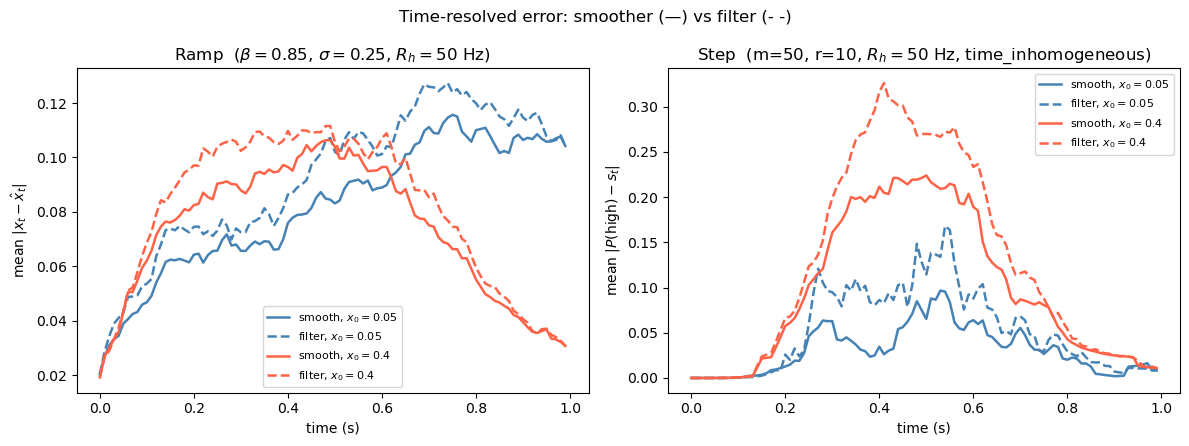

In [42]:
# ── Figure B: Time-resolved error ─────────────────────────────────────────────
np.random.seed(42)
ramp_errors = {}
step_errors = {}

for x0 in [X0_LOW, X0_HIGH]:
    # Ramp
    Ps, pi = build_ramp_hmm(K=K, beta=BETA_FS, sigma=SIGMA_FS, T=T, x0=x0)
    lams   = Rh * x_by_state * DT
    _, xs, _, spikes = simulate_discrete_ramp(T=T, pi=pi, Ps=Ps, n_trials=N_TRIALS_FS)
    s_e = np.zeros(T); f_e = np.zeros(T)
    for tr in range(N_TRIALS_FS):
        ll = inference.poisson_logpdf(spikes[tr].astype(int), lams.copy())
        ps, _ = inference.hmm_expected_states(pi, Ps, ll, filter=False)
        pf, _ = inference.hmm_expected_states(pi, Ps, ll, filter=True)
        s_e += np.abs(xs[tr] - ps @ x_by_state)
        f_e += np.abs(xs[tr] - pf @ x_by_state)
    ramp_errors[(x0, 'smooth')] = s_e / N_TRIALS_FS
    ramp_errors[(x0, 'filter')] = f_e / N_TRIALS_FS

    # Step
    Ps, pi, lams = build_step_hmm_for_inference(MODEL_TYPE_FS, T, M_FS, R_FS, x0, Rh)
    _, _, _, spikes, jumps = simulate_discrete_step(
        Ps=Ps, pi=pi, T=T, x0=x0, Rh=Rh, n_trials=N_TRIALS_FS
    )
    s_e = np.zeros(T); f_e = np.zeros(T)
    for tr in range(N_TRIALS_FS):
        ll = inference.poisson_logpdf(spikes[tr].astype(int), lams.copy())
        ps, _ = inference.hmm_expected_states(pi, Ps, ll, filter=False)
        pf, _ = inference.hmm_expected_states(pi, Ps, ll, filter=True)
        true_s = (np.arange(T) >= jumps[tr]).astype(float)
        s_e += np.abs(ps[:, -1] - true_s)
        f_e += np.abs(pf[:, -1] - true_s)
    step_errors[(x0, 'smooth')] = s_e / N_TRIALS_FS
    step_errors[(x0, 'filter')] = f_e / N_TRIALS_FS

colours = {X0_LOW: 'steelblue', X0_HIGH: 'tomato'}
fig_b, axes_b = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes_b[0]
for x0 in [X0_LOW, X0_HIGH]:
    c = colours[x0]
    ax.plot(time, ramp_errors[(x0,'smooth')], '-',  color=c, lw=1.8, label=f'smooth, $x_0={x0}$')
    ax.plot(time, ramp_errors[(x0,'filter')], '--', color=c, lw=1.8, label=f'filter, $x_0={x0}$')
ax.set_xlabel('time (s)'); ax.set_ylabel(r'mean $|x_t - \hat{x}_t|$')
ax.set_title(fr'Ramp  ($\beta={BETA_FS}$, $\sigma={SIGMA_FS}$, $R_h={Rh}$ Hz)'); ax.legend(fontsize=8)

ax = axes_b[1]
for x0 in [X0_LOW, X0_HIGH]:
    c = colours[x0]
    ax.plot(time, step_errors[(x0,'smooth')], '-',  color=c, lw=1.8, label=f'smooth, $x_0={x0}$')
    ax.plot(time, step_errors[(x0,'filter')], '--', color=c, lw=1.8, label=f'filter, $x_0={x0}$')
ax.set_xlabel('time (s)'); ax.set_ylabel(r'mean $|P(\mathrm{high}) - s_t|$')
ax.set_title(f'Step  (m={M_FS}, r={R_FS}, $R_h={Rh}$ Hz, {MODEL_TYPE_FS})'); ax.legend(fontsize=8)

fig_b.suptitle('Time-resolved error: smoother (—) vs filter (- -)', fontsize=12)
plt.tight_layout(); plt.show()



Computing excess-error grids (may take ~60 s)...
Done.


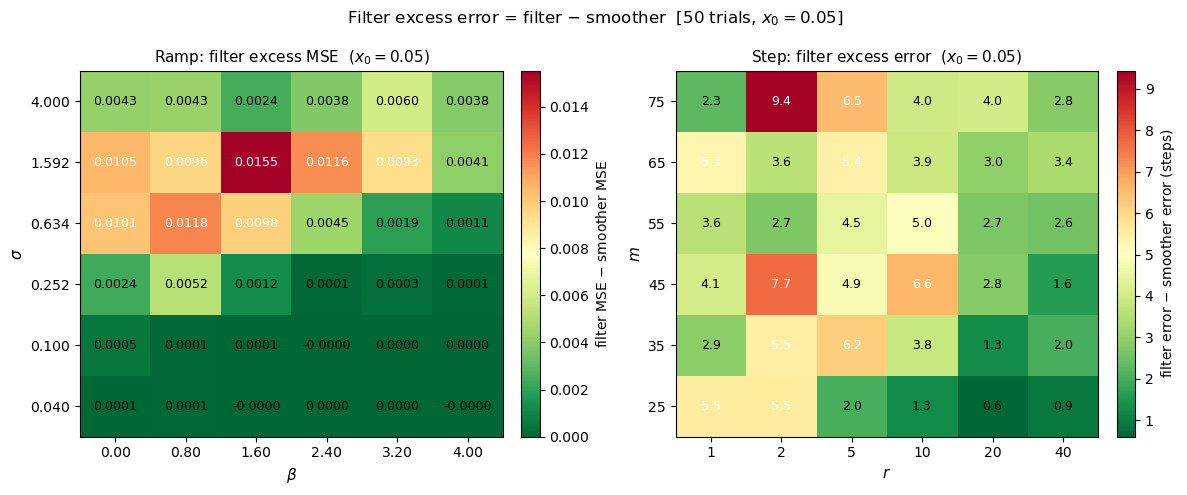

In [46]:

# ── Figure C: Filter excess-error heatmaps ────────────────────────────────────
print("Computing excess-error grids (may take ~60 s)...")

x_st_c = np.arange(K) / (K - 1)

# Ramp: smoother and filter MSE grids
ramp_s_grid = np.zeros((len(BETA_EX), len(LOG_SIG_EX)))
ramp_f_grid = np.zeros_like(ramp_s_grid)
for i, beta in enumerate(BETA_EX):
    for j, log_sig in enumerate(LOG_SIG_EX):
        sigma = np.exp(log_sig)
        Ps, pi = build_ramp_hmm(K=K, beta=beta, sigma=sigma, T=T, x0=X0_LOW)
        lams   = Rh * x_st_c * DT
        _, xs, _, spikes = simulate_discrete_ramp(T=T, pi=pi, Ps=Ps, n_trials=N_EXCESS)
        s_m, f_m = [], []
        for tr in range(N_EXCESS):
            ll = inference.poisson_logpdf(spikes[tr].astype(int), lams.copy())
            ps, _ = inference.hmm_expected_states(pi, Ps, ll, filter=False)
            pf, _ = inference.hmm_expected_states(pi, Ps, ll, filter=True)
            s_m.append(np.mean((xs[tr] - ps @ x_st_c) ** 2))
            f_m.append(np.mean((xs[tr] - pf @ x_st_c) ** 2))
        ramp_s_grid[i, j] = np.mean(s_m)
        ramp_f_grid[i, j] = np.mean(f_m)

ramp_excess = ramp_f_grid - ramp_s_grid

# Step: smoother and filter jump-time error grids
step_s_grid = np.zeros((len(R_EX), len(M_EX)))
step_f_grid = np.zeros_like(step_s_grid)
for i, r in enumerate(R_EX):
    for j, m in enumerate(M_EX):
        Ps, pi, lams = build_step_hmm_for_inference(
            MODEL_TYPE_FS, T, int(m), int(r), X0_LOW, Rh
        )
        _, _, _, spikes, jumps = simulate_discrete_step(
            Ps=Ps, pi=pi, T=T, x0=X0_LOW, Rh=Rh, n_trials=N_EXCESS
        )
        s_e, f_e = [], []
        for tr in range(N_EXCESS):
            ll   = inference.poisson_logpdf(spikes[tr].astype(int), lams.copy())
            ps, _ = inference.hmm_expected_states(pi, Ps, ll, filter=False)
            pf, _ = inference.hmm_expected_states(pi, Ps, ll, filter=True)
            ab_s = np.where(ps[:, -1] > 0.5)[0]; inferred_s = ab_s[0] if len(ab_s) > 0 else T
            ab_f = np.where(pf[:, -1] > 0.5)[0]; inferred_f = ab_f[0] if len(ab_f) > 0 else T
            s_e.append(abs(inferred_s - jumps[tr]))
            f_e.append(abs(inferred_f - jumps[tr]))
        step_s_grid[i, j] = np.mean(s_e)
        step_f_grid[i, j] = np.mean(f_e)

step_excess = step_f_grid - step_s_grid
print("Done.")

sig_labels_ex  = [f'{np.exp(v):.3f}' for v in LOG_SIG_EX]
beta_labels_ex = [f'{b:.2f}' for b in BETA_EX]
m_labels_ex    = [str(m) for m in M_EX]
r_labels_ex    = [str(r) for r in R_EX]

fig_c, axes_c = plt.subplots(1, 2, figsize=(12, 5))

ax = axes_c[0]
im = ax.imshow(ramp_excess.T, origin='lower', aspect='auto', cmap='RdYlGn_r')
cbar = fig_c.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('filter MSE $-$ smoother MSE', fontsize=10)
thresh = 0.55 * ramp_excess.max()
for i in range(len(LOG_SIG_EX)):
    for j in range(len(BETA_EX)):
        v = ramp_excess[j, i]
        ax.text(j, i, f'{v:.4f}', ha='center', va='center', fontsize=9,
                color='white' if v > thresh else 'black')
ax.set_xticks(range(len(BETA_EX)));    ax.set_xticklabels(beta_labels_ex)
ax.set_yticks(range(len(LOG_SIG_EX))); ax.set_yticklabels(sig_labels_ex)
ax.set_xlabel(r'$\beta$', fontsize=11); ax.set_ylabel(r'$\sigma$', fontsize=11)
ax.set_title(f'Ramp: filter excess MSE  ($x_0={X0_LOW}$)', fontsize=11)

ax = axes_c[1]
im = ax.imshow(step_excess.T, origin='lower', aspect='auto', cmap='RdYlGn_r')
cbar = fig_c.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('filter error $-$ smoother error (steps)', fontsize=10)
thresh = 0.55 * max(step_excess.max(), 1e-9)
for i in range(len(M_EX)):
    for j in range(len(R_EX)):
        v = step_excess[j, i]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9,
                color='white' if v > thresh else 'black')
ax.set_xticks(range(len(R_EX))); ax.set_xticklabels(r_labels_ex)
ax.set_yticks(range(len(M_EX))); ax.set_yticklabels(m_labels_ex)
ax.set_xlabel('$r$', fontsize=11); ax.set_ylabel('$m$', fontsize=11)
ax.set_title(f'Step: filter excess error  ($x_0={X0_LOW}$)', fontsize=11)

fig_c.suptitle(
    f'Filter excess error = filter $-$ smoother  [{N_EXCESS} trials, $x_0={X0_LOW}$]',
    fontsize=12
)
plt.tight_layout(); plt.show()

#### Block 5 analysis: Filtering vs smoothing — qualitative observations

**Figure A — Visual comparison.** On each example trial, the filter (dashed) visibly trails behind the smoother (solid). For the ramp, the filter underestimates $x_t$ in the rising phase; it takes several bins of elevated spike counts before it adjusts upward. For the step, the filter remains near zero for several time steps after the true jump before P(high) begins to rise, while the smoother transitions much more sharply around the true jump time.

**Figure B — Time-resolved error.** The filter error curve (dashed) lies above the smoother (solid) throughout the middle of each trial, confirming the visual impression. For the ramp, the gap is largest around $t = 0.4$–$0.6$ where $x_t$ is rising fastest — the smoother benefits most from "looking ahead" when the trajectory is changing. For the step model, the filter error peaks sharply just after the jump (it needs several post-jump spikes to gain confidence), whereas the smoother's peak is lower and narrower. Both curves converge at $t = T$ where filter and smoother necessarily agree. The high-$x_0$ regime (red curves) shows higher absolute error for both methods, and a widened gap between filter and smoother — weak signal makes future observations more valuable.

**Figure C — Filter excess error heatmaps.** The excess (filter $-$ smoother) quantifies precisely how much filtering costs relative to smoothing. For the ramp, the excess is largest at high $\beta$, low $\sigma$ — regimes where the trajectory evolves deterministically and future observations are highly informative about the current state. When the trajectory is noisy (high $\sigma$), the smoother gains less from future data because those observations are themselves uncertain, narrowing the gap. For the step model, excess is largest at small $m$ (early jumps) — once the jump has occurred, all future spikes are post-jump and the smoother can retroactively confirm the transition with high confidence, while the filter must wait. Large $r$ also increases excess error: a sharp, concentrated jump is easier for the smoother to pinpoint from the future but harder for the filter to detect in real time.

**Summary.** The filter is the appropriate choice only for online (causal) inference where future observations are unavailable. In our offline analysis setting, the smoother always outperforms the filter, with the largest advantage precisely where inference is easiest (high SNR, sharp events) — because in those regimes future observations carry the most additional information.

# Week 3: Inference of model parameters & model selection

This week we will proceed to the inference of model parameters (aka learning or fitting of model parameters), and preliminary model selection.

For Bayesian inference of parameters, we would like to compute the posterior distribution over model parameters, $\Theta$, given a *dataset* of observed spike trains:

$$ P(\Theta\, |\, \mathrm{data}\!=\!\{(n_t)_{t=1}^T\}, \mathcal{M}) $$

where the observed data are the set of spike trains in multiple trials and $\mathcal{M}$ ($ =$ *ramp* or *step*) denotes the model. According to the Bayes rule

$$ P(\Theta| \mathrm{data}, \mathcal{M}) \propto P(\mathrm{data}|\Theta, \mathcal{M}) P(\Theta| \mathcal{M}), \qquad\qquad (3.1) $$

where $P(\Theta| \mathcal{M})$ is the prior distribution over parameters and $P(\mathrm{data}|\Theta, \mathcal{M})$ is the model's likelihood function. Calculating the posterior distribution is hard  in general, since the  expression on the right hand side of Eq. (3.1) is not normalized (below we will refer to this expression  as the **unnormalized posterior**), and calculating the normalization constant requires integrating or summing over the possibly high-dimensional space of parameters. The same is true if we want to calculate the expectation of some function of the parameters (in particular their posterior expectation $\mathbb{E}[\Theta| \text{data}, \mathcal{M}]$): again we have to integrate over the parameters. In general, the computational cost of this integration grows exponentially in the number of parameters (or the dimension of parameter space). Thus Bayesian methods almost inevitably rely on one or another type of approximation for calculating the posterior.

In our project, the models have only 3 unknown parameters to be inferred, and the above problem is not prohibitive. However, if, e.g., we approximate the integral by a sum over a discretized 3D grid of points, such that the grid partitions each parameter's range of values (as determined by the prior) into, say, only $M = 10$ sub-intervals, we will have to sum over $M^3$ points, which requires $M^3 = 1000$ evaluations of the likelihood. In our case, at each point of the grid, the likelihood or its logarithm, can be calculated using the forward pass of the forward-backward algorithm (those curious about the details: see the section Model Log-likelihood of the [notes on the FBA](https://github.com/ghennequin/gg3/blob/main/fwdbwd.ipynb)). Note that this requires order $T$ matrix multiplications, each involving order $K^2$ arithmetic operations for $K$ Markov states; thus evaluation of the log-likelikehood for each value of parameters has cost $O(K^2 T)$. Thus computing the likelihood is relatively expensive (even if on our laptops it can be evaluated in a fraction of a second), and evaluating the posterior on such a grid has computational cost $O(M^d K^2 T)$, where for us $d=3$, though, in some of the tasks below, $d=2$.                                                                                                                
Use the function `hmm_normalizer` of `inference.py` to calculate the model **log-** likelihood using the forward pass.

**Prior distributions:**
Unless instructed otherwise, use a uniform prior distribution on the parameters, on specified ranges. For $\sigma$ of the ramp model it will be more sensible to use a uniform prior on its logarithm. In fact, to make things easier you should work with $\ln \sigma$, when evaluating the unnormalized posterior, and in the grid method, construct the (regular) grid for $\ln \sigma$, instead of $\sigma$ (but obviously exponentiate $\ln \sigma$ when passing to your likelihood function, and when calculating posterior estimates of the parameters calculate the posterior mean or error of the exponential of the $\ln \sigma$ values). Sensible ranges are as follows:

$\beta \in [0, 4]$

$\ln\sigma \in [\ln(0.04), \ln(4)]$

$r \in \{1,2, \ldots, 6\}$ 

$m \in [0, 3T/4]$

$x_0 \in [0, 0.5]$

**Hyperparameters:** Unless otherwise stated, use $T = 100$ and for the ramp model: $K = 100$.

#### Note on the step model's likelihood evaluation:
Before we proceed to the tasks, a note on the $K = r + 1$ hidden-state HMM implementation of the step model (you can ignore this note if you have opted to use the time-inhomogeneous Markov chain implementation instead). As you may have noted, the jump times in the $(r+1)$-state implementation will have a delay of $r$ steps compared to the draws form the $\mathrm{NB}(m, r)$ distribution as used in Week 1. For simulating a trial with $T$ time steps, this issue can be dealt with by a time-shift, at the expense of simulating the Markov chain for $r$ extra steps: simulate $T+r$ steps but only consider the last $T$ steps, and only generate spikes in those final $T$ steps. This week, however, we would like to evaluate the likelihoods of the two models, on the *same* set of spike trains on the interval $t = 1:T$, using the forward pass of FBA. In this case, the necessary compensation for the extra, observation-less $r$ steps can be made by the following modification to the input argument `ll` that you will pass to the function `hmm_normalizer`:
- evaluate this array as normal, as the $T \times K$ matrix of observed probabilities of $n_{1:T}$ in all possible hidden states;
- then prepend $r$ rows with all elements equal to 0 to the top of this matrix to make it a $(r+T)\times K$ matrix instead.

(If curious, you can verify that this is the correct way of generalizing the forward pass to  cases with "missing observations" by inspecting the [details of the forward pass](https://github.com/ghennequin/gg3/blob/main/fwdbwd.ipynb).) Note that this compensation
is exactly equivalent to running the forward pass on the original $T$ steps (that have spike observations), but using $\mathcal{T}^{r} \pi$ -- where $\mathcal{T}$
is transition matrix -- as the initial Markov chain probability distribution instead of $\pi$. (This second method is actually computationally preferable, since -- for a given values of $r$ or $m$ -- you calculate $\mathcal{T}^{r} \pi$ once, before using it in the FWA to be run on all spike trains.)

### Task 3.1: Grid approximation

We will start this task by fixing the value of $x_0$ to 0.2 (for both models); so we will not infer it, but  assume it known. Construct a regular 2D grid on each model's parameter space (on the ranges given above, and using $\ln \sigma$ instead of $\sigma$) with $M$ grid points along each coordinate axis, thinking of each grid point as <u>*the center*</u> of its "assigned" sub-interval. Start by relatively high values of $M$, e.g. $M=30$.

(For one calculation of the posterior over all grid points, going to higher $M$'s is also feasible, but since you want to experiment and explore with different parameters and hyperparameters, you should compromise on using higher values of $M$. But ultimately use your own judgement, in particular by using $M < 30$ if necessary. Similarly, in the sub-tasks below, make reasonable choices of the number of different cases of true parameters, etc., that you explore. It is probably wise to start small-scale, in a first pass through all sub-tasks, and after you have a rough overview of computational times, inference behaviour, etc, do  more thorough final runs going over a larger number of possibilities and/or using higher $M$ values, which would take longer to compute.)

For each model simulate a dataset of $N_{\rm trial}$ spike trains, and for each dataset, evaluate *that* model's log-likelihood on all grid points (by summing the log-likelihood of all trials), and form the *normalized* posterior by using Bayes' rule Eq. (3.1).

**3.1.1:** Visualize the (approximate) posterior on the grid (e.g. using `plt.imshow`) with a  super-imposed point representing the true parameters. Repeat for different true parameter values (within the ranges of the prior distribution) and for different number of trials (over a range from 1 to 400). Document your observations of systematic dependence of the posterior on the number of trials. Similarly, note any systematic changes in behaviour for different values of the true parameters. 

**3.1.2:** In addition to visualisation, evaluate the posterior expectations of the parameters as their estimates, as well as their posterior standard deviations (as measures of their posterior uncertainties or  "error bars" for their estimates).  Given the true parameter value, you can also evaluate the actual estimation error of different parameters, for  dataset of different sizes (different number of trials) or choices of true parameters (averaging the error over a few, even just 2-3, datasets when $N_{trial}$ is low). Make appropriate plots. 

Also quantitatively compare the estimation errors with the posterior uncertainties of different parameters. 
What do you expect for this relationship, and what do you observe?

### Task 3.2: Model selection (grid based)

The Bayesian method for model selection is the computation of so-called Bayes factors, i.e. the model posteriors (for $\mathcal{M} = $ *ramp* or *step*):

$$P(\mathcal{M}| \mathrm{data}) \propto P(\mathrm{data}| \mathcal{M}) P(\mathcal{M})$$

where $P(\mathcal{M})$ denotes the prior probability of each model (and $\mathrm{data}=\{(n_t)_{t=1}^T\}$), which we will take to be 0.5 throughout. In this case, the posterior model probabilities are proportional to their so-called **marginal likelihoods** $P(\mathrm{data}| \mathcal{M})$, and model selection can be entirely based on the **marginal likelihood ratio (MLR)**, also known as the **Bayes factor**:

$$R = \frac{P(\mathrm{data}| \mathcal{M}=ramp)}{P(\mathrm{data}| \mathcal{M}=step)}\qquad\qquad (3.2)$$

or its logarithm, with the ramp model chosen if $R>1$ or $\ln R > 0$, and vice versa.

$P(\mathrm{data}| \mathcal{M})$ is called marginal likelihood because its calculation involves integrating out (or marginalizing) model parameters:

$$P(\mathrm{data}| \mathcal{M}) = \int P(\mathrm{data}|\Theta, \mathcal{M}) P(\Theta| \mathcal{M})\, d\Theta.\qquad\qquad (3.3) $$

Comparison with Eq. (3.1) shows that this is *exactly* the normalizing constant (the denominator of Bayes rule) for the unnormalized posterior over model parameters. (The denominator of the Bayes rule 3.1, is also known as "evidence", as it quantifies the strength of evidence in favor of the model.) So you have already evaluated the marignal likelihoods in Task 3.1 when you normalized the posteriors (up to approximating the integral with a sum over grid points). (**However,** you need to make sure that you have included the appropriate (approximate) $d\Theta$'s in the formula. This is the volume of each square in your grid, and for integer $r$ the number of integers within the coarse-grid, if using a coarse-grid. Also note that this depends on your choice of normalization of the prior; ultimately what matters is that if you replace $P(\mathrm{data}|\Theta, \mathcal{M})$ in Eq. (3.3) with 1, the integral or grid-sum should evaluate to 1.)


Do model selection, based on the MLR, for datasets of different sizes (number of trials) and quantify the two different error rates.

- **3.2.1:** First do this by sampling the ("true") parameters, used for generating a dataset from each model, from that model's prior parameter distribution.

- **3.2.2:** Repeat this with "mismatched" parameter priors: without changing the parameter-sampling distribution (i.e. keep sampling parameters exactly as in 3.2.1), use different priors for parameter inference. Specifically, use truncated Gaussian prior distributions (uncorrelated/independent across different parameters) that are centered in the middle of the parameter ranges given above for $\beta$, $\sigma$ and $m$, but at the low end for $r$ (i.e. centered at $r=1$). Try different values for the corresponding prior Gaussian standard deviations (SD). Speficially, for all parameters choose their SD to be the *same* fraction of the length of their respective range, but try 2 or 3 different values for this fraction (say, 1/2, 1/4, etc.) [**§**]. What happens to the error rates? Describe how this depends on the dataset size (try 25 vs. 100 trials), as well as on the degree of divergence between the data-generation distribution and the priors.

- **3.2.3:** Now evaluate the error rates when you also sample the parameters from centered truncated Gaussians; thus the prior distribution and parameter sampling distributions are now matched again but both are Gaussian, rather than uniform. In this case fix the fraction used for setting the SDs of the truncated Gaussian priors to 1/4. In addition, using the same parameter sampling distributions (and not the distributions you used in Task 1.4 of Week 1), re-evaluate the two error rates of the ad-hoc method that you developed in Task 1.4 (without re-training that algorithm or changing any of its hyperparameters -- i.e. apply the exact same code to spike-train datasets generated by model parameters sampled from the new, truncated Gaussians distribution). How do the error rates compare with those obtained in Week 1, and how do they differ from the error rates of the Bayesian method? What conclusions can you draw from these comparisons about any advantages or drawbacks of Bayesian model selection?

--- 

**§:** Note that we are still using the discritized parameter grid (used to approximate the marginal likelihood integral by a discrete sum), so by Gaussian distribution we really mean truncated Gaussians. More precisely let the prior probability of each choice of $\Theta$ in the grid be given by the expression for the Gaussian probability density, but then normalize this prior  to sum to 1 over the parameter grid. 

# Week 4: Model mismatch / brittleness

In this task we will explore the effect of **model mismatch** on model selection, and the related concept of **brittleness** (a term coined in Chandrasekaran et al. 2018). As may be intuitive, mismatch of either model with the true data generative process would lead to additional systematic errors in model selection (as a means to hypothesis testing).
Brittleness refers to a special case of this: in order to quantitatively evaluate empirical evidence for a conceptual hypothesis (such as whether a LIP neuron "continuously
accumulates evidence by ramping up its activity", or whether "its firing rate abruptly jumps during a trial at a random time") we need to concoct a precise mathematical model to encapsulate the alternative conceptual hypotheses. In order to carry out probabilistic/Bayesian inference we further need these models to be probabilistic models, with a likelihood function and a prior distribution over parameters. In the process of designing such mathematical models, in general, and probabilistic models, in particular, various choices need to be made for different aspects of the model which are independent of the conceptual hypotheses and are not constrained by them.

For example, in our case, a model that is identical to our step model, but has a jump time distribution that is not negative binomial, but, say, a uniform distribution, is still consistent with the conceptual hypothesis of a discontinous jump in the firing rate, as opposed to a continuous ramp. As another example, our two competing hypotheses differ only in their predictions for the behaviour of latent firing rates, and are silent on the precise mechanism or statistical form of spiking based on those firing rates. However, in order to build a probabilistic model of our observed data (spike counts) we needed to make a modeling choice and decided to model spike counts as Poisson distributed (conditional on rates).

But what if reality deviates from these assumptions? What effect would such deviations have on our inferences about the true mechanism underlying the data? Finally, what can we do to reduce the brittleness of hypothesis testing? This task is intended to provide insight about these questions. 

For all the tasks below, use $M = 10$, and unless otherwise instructed, $N_{\rm trials} = 25$, to save on computational time. For number of datasets (to evaluate error rates) use 10 datasets at a minimum, and no need to exceed 100. (In general, be strategic about choice of the number of datasets. If you see, based on small-scale explorations, that a trend that is the subject of a sub-task or question is visible for a smaller number of datasets, you don't need to use more datasets.)

### Task 4.1: Non-Poissonian spiking

(For this task fix the value of $x_0$ and $R_h$ to 0.5 and 25 Hz, respectively (for both models); as above, your inference algorithm will "know" the true value of these, as used for data generation.)

Here you will study the effect of (unaccounted) non-Poissonian spiking on the model selection. The function `gamma_isi_point_process` in `models.py` allows you to simulate non-Poissonian spikes within a certain family for which inter-spike interval (ISI)  distributions deviate from the exponential distribution which is the ISI distribution under Poisson spiking (this corresponds to the special case of `shape = 1` for the parameter of `gamma_isi_point_process`). (You are not directly interested in ISI's and their distribution for the tasks.) 

Generalise your code implementing the HMM-based ramp and step models to emit spikes according to the new distribution family (inspection of the `emit` methods of the ramp and step model classes in `models.py`  shows you how to use `gamma_isi_point_process`).

**4.1.1** Investigate the behavior of the two types of model-selection error rate (the mis-classification rate for each case of true model) with increasing values of the `shape` parameter of `gamma_isi_point_process` (do not use values of `shape` less than 1, and no need to go above 5). Calculate and report the error rates by sampling true parameters uniformly from the grid you used in Task 3.2.1 (making sure they are chosen to produce ramp-like PSTH's). In this sub-task use $N_{\rm trials} = 25$.

How does deviation from Poisson  (with `shape` > 1) affect the two error rates? Does it bias the model selection to one or the other model systematically? If so, towards which model?  

**4.1.2** The model-mismatch due to non-Poisson spiking is an example of mismatch of a model's likelihood with the true data-generating model. A mismatch of model prior with the true distribution from which true model parameters are sampled (in the real world, this could correspond to the variation of parameters across real LIP neurons, for example) can also affect model selection. You have already investigated this in 3.2.2. Investigate the difference in the effect of number of trials on model misclassification biases, for the two cases of prior mismatch and unaccounted non-Poissonian spiking (choose a sensible degree of prior mismatch based on your explorations in 3.2.2). If there is a systematic difference, try to provide an explanation. (You can use $N_{\rm trials} = 10, 20, 50, 200$ --and higher if possible-- and you can fix the true parameters, including `shape`, to reasonable values; reasonable according to your previous findings.)

### Task 4.2: Understanding the effects of non-Poissonian spiking

This task only involves simulation (spike train generation) of the HMM models (or the models from `models.py`, up to you) with `gamma_isi_point_process` used for spike emission. By remaking the sort of plots you made in Week 1 (e.g. raster plots and plots of PSTH and Fano Factor vs. time) for the non-Poissonian model and observing its behavior, answer the following questions:

- How does `shape` affect spiking quality and the resulting Fano Factor behaviour?
- Based on your observations, try to explain the effects  that you observed in **4.1.1** of  non-Poisson spiking on model selection errors. 